In [3]:
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 974.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 15.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninsta

In [ ]:
!pip install TA-Lib

In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt

# --- 1. הגדרות וטעינת נתונים ---
symbol = "DLEKG.TA"
benchmark = "^TA125.TA"
data = yf.download(symbol, period="300d", interval="1d")
bench_data = yf.download(benchmark, period="300d", interval="1d")

df = data.copy()
df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
df = df.dropna()

# --- 2. חישוב אינדיקטורים טכניים בסיסיים ---
df['ema200'] = ta.ema(df['Close'], length=200)
df['ema50'] = ta.ema(df['Close'], length=50)
df['rsi'] = ta.rsi(df['Close'], length=14)
macd = ta.macd(df['Close'])
df['macd_hist'] = macd['MACDh_12_26_9']
df['plus_di'] = ta.adx(df['High'], df['Low'], df['Close'])['DMP_14']

# --- 3. לוגיקת VCP Squeeze (חדש) ---
bbands = ta.bbands(df['Close'], length=20, std=2.0)
df['bb_lower'] = bbands['BBL_20_2.0_2.0'] # Corrected column name
df['bb_upper'] = bbands['BBU_20_2.0_2.0'] # Corrected column name
df['tr'] = ta.true_range(df['High'], df['Low'], df['Close'])
df['maK'] = ta.sma(df['Close'], 20)
df['rK'] = ta.sma(df['tr'], 20)
# תנאי VCP: רצועות בולינגר בתוך טווח ה-ATR
df['vcp_squeeze'] = (df['bb_lower'] > df['maK'] - df['rK'] * 1.5) & \
                    (df['bb_upper'] < df['maK'] + df['rK'] * 1.5)

# --- 4. תמיכה וספיגה מוסדית (חדש) ---
# Near Support (מבוסס Pivot Low פשוט)
df['pivot_low'] = df['Low'].rolling(window=5).min()
df['is_near_support'] = (df['Close'] <= df['pivot_low'] * 1.025) & \
                        (df['Close'] >= df['pivot_low'] * 0.98)

# Institutional Absorption
df['avg_v'] = ta.sma(df['Volume'], length=10)
df['rvol'] = df['Volume'] / df['avg_v']
df['inst_absorption'] = (df['rvol'] > 1.5) & (df['Close'] > (df['Low'] + (df['High'] - df['Low']) * 0.66))

# --- 5. מומנטום וזרימת כסף ---
df['macd_momentum'] = (df['macd_hist'] > 0) & (df['macd_hist'] > df['macd_hist'].shift(1))
df['cmf'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

# --- 6. חוזק יחסי (RS) וסטיות ---
bench_returns = bench_data['Close'].pct_change(63)
stock_returns = df['Close'].pct_change(63)
df['rs_value'] = stock_returns - bench_returns.reindex(stock_returns.index)['^TA125.TA']

def detect_div(price, indicator, lookback=10):
    lows = (price == price.rolling(lookback).min())
    div = (price < price.shift(lookback)) & (indicator > indicator.shift(lookback)) & lows
    return div.rolling(7).max() > 0

df['bull_div_rsi'] = detect_div(df['Low'], df['rsi'])
df['bull_div_macd'] = detect_div(df['Low'], df['macd_hist'])

# --- 7. תבניות נרות ---
df['is_hammer'] = ta.cdl_pattern(df['Open'], df['High'], df['Low'], df['Close'], name="hammer")
df['is_engulfing'] = ta.cdl_pattern(df['Open'], df['High'], df['Low'], df['Close'], name="engulfing")
df['bull_pattern'] = (df['is_hammer'] != 0) | (df['is_engulfing'] != 0)

# --- 8. חישוב הניקוד המשוקלל המלא (100 נקודות) ---
df['score'] = 0.0
df.loc[df['Close'] > df['ema200'], 'score'] += 15       # מגמה ראשית
df.loc[df['ema50'] > df['ema200'], 'score'] += 15       # אישור מגמה
df.loc[df['bull_div_rsi'], 'score'] += 10               # סטיית RSI
df.loc[df['bull_div_macd'], 'score'] += 10              # סטיית MACD
df.loc[df['macd_momentum'], 'score'] += 10              # מומנטום
df.loc[df['rs_value'] > 0, 'score'] += 10               # חוזק יחסי
df.loc[df['cmf'] > 0, 'score'] += 5                     # זרימת כסף
df.loc[df['vcp_squeeze'], 'score'] += 5                 # VCP
df.loc[df['is_near_support'], 'score'] += 5             # תמיכה
df.loc[df['bull_pattern'], 'score'] += 5                # נרות
df.loc[df['inst_absorption'], 'score'] += 5             # ספיגה מוסדית
df.loc[df['rvol'] > 1.2, 'score'] += 5                  # ווליום יחסי

# --- 9. איתותים ---
df['dist_ema200'] = ((df['Close'] - df['ema200']) / df['ema200']) * 100
df['trend_safe'] = (df['Close'] > df['ema200']) & (df['cmf'] > 0) & (df['dist_ema200'] <= 15.0)
df['is_buy'] = (df['trend_safe']) & (df['score'] >= 70)
df['is_strong_buy'] = (df['trend_safe']) & (df['score'] >= 85)

# --- 10. הצגת תוצאות ---
last_row = df.iloc[-1]
print(f"--- Analysis for {symbol} ---")
print(f"Total Score: {last_row['score']}/100")
print(f"Signal: {'STRONG BUY' if last_row['is_strong_buy'] else 'BUY' if last_row['is_buy'] else 'WAIT'}")

/tmp/ipykernel_7697/3443460663.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, period="300d", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_7697/3443460663.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bench_data = yf.download(benchmark, period="300d", interval="1d")
[*********************100%***********************]  1 of 1 completed


[i] Requires TA-Lib to use hammer. (pip install TA-Lib)
[i] Requires TA-Lib to use engulfing. (pip install TA-Lib)
--- Analysis for DLEKG.TA ---
Total Score: 45.0/100
Signal: WAIT


In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
import warnings

# השתקת אזהרות
warnings.filterwarnings("ignore")

# ==========================================
# ⚙️ פרמטרים לשינוי
# ==========================================
MIN_SCORE_THRESHOLD = 70  # שנה את המספר הזה כדי לשנות את רף הסינון
BENCHMARK = "^GSPC"
PERIOD = "300d"

# --- רשימת המניות ---
assets = [
    "AURA.TA", "OPCE.TA", "ORA.TA", "ICL.TA", "ARPT.TA", "INRM.TA",
    "ESLT.TA", "ALHE.TA", "ELTR.TA", "ECP.TA", "ELWS.TA", "AMOT.TA",
    "ENLT.TA", "ENRG.TA", "ORL.TA", "BEZQ.TA", "BIG.TA", "GCTY.TA",
    "GNRS.TA", "GVYM.TA", "GILT.TA", "DLEKG.TA", "DELT.TA", "DIMRI.TA",
    "DNL.TA", "ILDC.TA", "HARL.TA", "ISRA.TA", "LUMI.TA", "LAHAV.TA",
    "LAPD.TA", "MZTF.TA", "MTRX.TA", "MTAV.TA", "MTRN.TA", "DIFI.TA",
    "MLSR.TA", "ISHS.TA", "NAWI.TA", "NVMI.TA", "NOFR.TA", "NWMD.TA",
    "NICE.TA", "PTNR.TA", "CEL.TA", "AZRG.TA", "POLI.TA", "FOX.TA",
    "PZBA.TA", "PRTC.TA", "FTAL.TA", "RIT1.TA", "RMLI.TA", "RATP.TA",
    "SHBA.TA", "SAE.TA", "STRS.TA", "SPEN.TA", "TDRN.TA", "TRPZ.TA", "AAPL","XLK", "XLF", "XLV", "XLY", "XLP", "XLI", "XLC", "XLE", "XLU", "XLB", "XLRE"
]

# 1. הכנת נתוני בנצ'מרק
bench_data = yf.download(BENCHMARK, period=PERIOD, interval="1d", progress=False)
if isinstance(bench_data.columns, pd.MultiIndex):
    bench_data.columns = bench_data.columns.get_level_values(0)
bench_returns = bench_data['Close'].pct_change(63)

def detect_div(price, indicator, lookback=10):
    if len(price) < lookback: return False
    lows = (price == price.rolling(lookback).min())
    div = (price < price.shift(lookback)) & (indicator > indicator.shift(lookback)) & lows
    return div.tail(7).any()

print(f"🔎 Scanning stocks for Score >= {MIN_SCORE_THRESHOLD}...\n")
print(f"{'Ticker':<10} | {'Score':<10} | {'Status'}")
print("-" * 35)

for symbol in assets:
    try:
        # 2. הורדת נתונים מניה בודדת
        data = yf.download(symbol, period=PERIOD, interval="1d", progress=False)
        if data.empty or len(data) < 200:
            continue

        df = data.copy()
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.dropna()

        # --- 3. חישוב אינדיקטורים טכניים ---
        df['ema200'] = ta.ema(df['Close'], length=200)
        df['ema50'] = ta.ema(df['Close'], length=50)
        df['rsi'] = ta.rsi(df['Close'], length=14)
        macd = ta.macd(df['Close'])
        df['macd_hist'] = macd.filter(like='MACDh').iloc[:,0]

        # VCP Squeeze
        bbands = ta.bbands(df['Close'], length=20, std=2.0)
        df['bb_lower'] = bbands.filter(like='BBL').iloc[:,0]
        df['bb_upper'] = bbands.filter(like='BBU').iloc[:,0]
        df['tr'] = ta.true_range(df['High'], df['Low'], df['Close'])
        df['maK'] = ta.sma(df['Close'], 20)
        df['rK'] = ta.sma(df['tr'], 20)
        df['vcp_active'] = (df['bb_lower'] > df['maK'] - df['rK'] * 1.5) & \
                           (df['bb_upper'] < df['maK'] + df['rK'] * 1.5)

        # תמיכה וספיגה
        df['pivot_low'] = df['Low'].rolling(window=5).min()
        df['is_near_support'] = (df['Close'] <= df['pivot_low'] * 1.025) & \
                                (df['Close'] >= df['pivot_low'] * 0.98)
        df['avg_v'] = ta.sma(df['Volume'], length=10)
        df['rvol'] = df['Volume'] / df['avg_v']
        df['inst_absorption'] = (df['rvol'] > 1.5) & \
                                (df['Close'] > (df['Low'] + (df['High'] - df['Low']) * 0.66))

        df['macd_momentum'] = (df['macd_hist'] > 0) & (df['macd_hist'] > df['macd_hist'].shift(1))
        df['cmf'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)
        df['rs_value'] = df['Close'].pct_change(63) - bench_returns.reindex(df.index).ffill()

        df['bull_div_rsi'] = detect_div(df['Low'], df['rsi'])
        df['bull_div_macd'] = detect_div(df['Low'], df['macd_hist'])

        # תבניות נרות
        try:
            is_ham = ta.cdl_pattern(df['Open'], df['High'], df['Low'], df['Close'], name="hammer")
            is_eng = ta.cdl_pattern(df['Open'], df['High'], df['Low'], df['Close'], name="engulfing")
            df['bull_pattern'] = (is_ham.iloc[:,0] != 0) | (is_eng.iloc[:,0] != 0)
        except:
            body = (df['Close'] - df['Open']).abs()
            df['bull_pattern'] = ((df['Low'] < df[['Open','Close']].min(axis=1)) & \
                                 ((df[['Open','Close']].min(axis=1) - df['Low']) > body * 2))

        # --- 4. חישוב הניקוד ---
        score = 0.0
        last = df.iloc[-1]

        if last['Close'] > last['ema200']: score += 15
        if last['ema50'] > last['ema200']: score += 15
        if last['bull_div_rsi']: score += 10
        if last['bull_div_macd']: score += 10
        if last['macd_momentum']: score += 10
        if last['rs_value'] > 0: score += 10
        if last['cmf'] > 0: score += 5
        if last['vcp_active']: score += 5
        if last['is_near_support']: score += 5
        if last['bull_pattern']: score += 5
        if last['inst_absorption']: score += 5
        if last['rvol'] > 1.2: score += 5

        # הדפסה רק אם הציון עומד בסף שהוגדר
        if score >= MIN_SCORE_THRESHOLD:
            print(f"{symbol:<10} | {int(score):>3}/100   | PASSED")

    except Exception:
        continue

print("\n--- Scan Finished ---")

ModuleNotFoundError: No module named 'pandas_ta'

In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
import warnings
from datetime import datetime, timedelta

# השתקת אזהרות
warnings.filterwarnings("ignore")

# ==========================================
# ⚙️ פרמטרים לשינוי
# ==========================================
MIN_SCORE_THRESHOLD = 65  # רף הניקוד להדפסה
BENCHMARK = "^TA125.TA"       # S&P 500
PERIOD = "8y"             # הורדת 8 שנים של נתונים
INTERVAL = "1wk"          # אינטרוול שבועי (Weekly)

# רשימת הנכסים המלאה
assets = [
    "XLK", "XLF", "XLV", "XLY", "XLP", "XLI", "XLC", "XLE", "XLU", "XLB", "XLRE",
    "AURA.TA", "OPCE.TA", "ORA.TA", "ICL.TA", "ARPT.TA", "INRM.TA",
    "ESLT.TA", "ALHE.TA", "ELTR.TA", "ECP.TA", "ELWS.TA", "AMOT.TA",
    "ENLT.TA", "ENRG.TA", "ORL.TA", "BEZQ.TA", "BIG.TA", "GNRS.TA",
    "GVYM.TA", "GILT.TA", "DLEKG.TA", "DIMRI.TA", "ILDC.TA", "HARL.TA",
    "ISRA.TA", "LUMI.TA", "LAHAV.TA", "LAPD.TA", "MZTF.TA", "MTRX.TA",
    "MTAV.TA", "MTRN.TA", "DIFI.TA", "MLSR.TA", "NAWI.TA", "NVMI.TA",
    "NOFR.TA", "NWMD.TA", "NICE.TA", "PTNR.TA", "CEL.TA", "AZRG.TA",
    "POLI.TA", "FOX.TA", "PRTC.TA", "FTAL.TA", "RIT1.TA", "RMLI.TA",
    "SAE.TA", "STRS.TA", "SPEN.TA", "TDRN.TA", "TRPZ.TA", "AAPL",
    "JPM", "BAC", "WFC", "C", "GS", "MS", "USB", "PNC", "AXP","MTRD.TA"
]

# 1. הורדת נתוני בנצ'מרק בשבועי (לחישוב RS)
bench_data = yf.download(BENCHMARK, period=PERIOD, interval=INTERVAL, progress=False)
if isinstance(bench_data.columns, pd.MultiIndex):
    bench_data.columns = bench_data.columns.get_level_values(0)
# חישוב שינוי רבעוני (12 שבועות בשבועי מקביל ל-63 יום ביומי)
bench_returns = bench_data['Close'].pct_change(12)

def detect_div(price, indicator, lookback=10):
    if len(price) < lookback: return False
    lows = (price == price.rolling(lookback).min())
    div = (price < price.shift(lookback)) & (indicator > indicator.shift(lookback)) & lows
    return div.tail(5).any()

print(f"🔎 Scanning Weekly Data (Interval: {INTERVAL}, Period: {PERIOD})")
print(f"Filtering for Score >= {MIN_SCORE_THRESHOLD}...\n")
print(f"{'Ticker':<10} | {'Score':<10} | {'Status'}")
print("-" * 35)

for symbol in assets:
    try:
        # 2. הורדת נתוני מניה (אחת-אחת) בשבועי
        data = yf.download(symbol, period=PERIOD, interval=INTERVAL, progress=False)
        if data.empty or len(data) < 200: # לוודא שיש מספיק נרות ל-EMA200 שבועי
            continue

        df = data.copy()
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.dropna()

        # --- 3. לוגיקה טכנית (זהה למקור - עכשיו רצה על נרות שבועיים) ---
        df['ema200'] = ta.ema(df['Close'], length=200)
        df['ema50'] = ta.ema(df['Close'], length=50)
        df['rsi'] = ta.rsi(df['Close'], length=14)
        macd = ta.macd(df['Close'])
        df['macd_hist'] = macd.filter(like='MACDh').iloc[:,0]

        # VCP Squeeze
        bbands = ta.bbands(df['Close'], length=20, std=2.0)
        df['bb_lower'] = bbands.filter(like='BBL').iloc[:,0]
        df['bb_upper'] = bbands.filter(like='BBU').iloc[:,0]
        df['tr'] = ta.true_range(df['High'], df['Low'], df['Close'])
        df['maK'] = ta.sma(df['Close'], 20)
        df['rK'] = ta.sma(df['tr'], 20)
        vcp_active = (df['bb_lower'] > df['maK'] - df['rK'] * 1.5) & \
                     (df['bb_upper'] < df['maK'] + df['rK'] * 1.5)

        # תמיכה וספיגה
        pivot_low = df['Low'].rolling(window=5).min()
        is_near_support = (df['Close'] <= pivot_low * 1.025) & (df['Close'] >= pivot_low * 0.98)
        avg_v = ta.sma(df['Volume'], length=10)
        rvol = df['Volume'] / avg_v
        inst_absorption = (rvol > 1.5) & (df['Close'] > (df['Low'] + (df['High'] - df['Low']) * 0.66))

        macd_momentum = (df['macd_hist'] > 0) & (df['macd_hist'] > df['macd_hist'].shift(1))
        cmf = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)
        # חוזק יחסי רבעוני (12 שבועות)
        rs_value = df['Close'].pct_change(12) - bench_returns.reindex(df.index).ffill()

        bull_div_rsi = detect_div(df['Low'], df['rsi'])
        bull_div_macd = detect_div(df['Low'], df['macd_hist'])

        # נרות (Fallback במקרה ואין TA-Lib)
        body = (df['Close'] - df['Open']).abs()
        bull_pattern = ((df['Low'] < df[['Open','Close']].min(axis=1)) & \
                       ((df[['Open','Close']].min(axis=1) - df['Low']) > body * 2))

        # --- 4. חישוב הניקוד ---
        score = 0.0
        last = df.iloc[-1]

        if last['Close'] > last['ema200']: score += 15
        if last['ema50'] > last['ema200']: score += 15
        if bull_div_rsi: score += 10
        if bull_div_macd: score += 10
        if macd_momentum.iloc[-1]: score += 10
        if rs_value.iloc[-1] > 0: score += 10
        if cmf.iloc[-1] > 0: score += 5
        if vcp_active.iloc[-1]: score += 5
        if is_near_support.iloc[-1]: score += 5
        if bull_pattern.iloc[-1]: score += 5
        if inst_absorption.iloc[-1]: score += 5
        if rvol.iloc[-1] > 1.2: score += 5

        # 5. הדפסה
        if score >= MIN_SCORE_THRESHOLD:
            print(f"{symbol:<10} | {int(score):>3}/100   | PASSED")

    except Exception:
        continue

print("\n--- Weekly Scan Finished ---")

🔎 Scanning Weekly Data (Interval: 1wk, Period: 8y)
Filtering for Score >= 65...

Ticker     | Score      | Status
-----------------------------------
DIMRI.TA   |  65/100   | PASSED
ISRA.TA    |  65/100   | PASSED
LAHAV.TA   |  65/100   | PASSED
SAE.TA     |  70/100   | PASSED

--- Weekly Scan Finished ---


In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np

def get_analyst_whale_fusion(ticker_symbol, benchmark_symbol="SPY", period="2y"):
    # 1. משיכת נתונים מ-Yahoo Finance
    ticker = yf.Ticker(ticker_symbol)
    df = ticker.history(period=period)

    bench = yf.Ticker(benchmark_symbol)
    df_bench = bench.history(period=period)

    if df.empty or df_bench.empty:
        return None

    # סנכרון נתונים בין המניה למדד
    combined = pd.concat([df['Close'], df_bench['Close']], axis=1, keys=['Close', 'Bench']).dropna()

    # --- Analyst Dashboard V19.0 Logic ---

    # אינדיקטורים בסיסיים
    df['EMA200'] = ta.ema(df['Close'], length=200)
    df['EMA50'] = ta.ema(df['Close'], length=50)
    df['RSI'] = ta.rsi(df['Close'], length=14)

    # MACD
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['MACD_hist'] = macd.filter(like='MACDh').iloc[:,0] # Corrected column access
    df['MACD_momentum'] = (df['MACD_hist'] > 0) & (df['MACD_hist'] > df['MACD_hist'].shift(1))

    # CMF (Chaikin Money Flow)
    df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

    # Relative Strength (RS) vs Benchmark
    rs_period = 63
    df['RS_Value'] = ((df['Close'] - df['Close'].shift(rs_period)) / df['Close'].shift(rs_period)) - \
                     ((df_bench['Close'] - df_bench['Close'].shift(rs_period)) / df_bench['Close'].shift(rs_period))

    # Beta calculation (20 days)
    returns = combined['Close'].pct_change()
    bench_returns = combined['Bench'].pct_change()
    df['Beta'] = ta.core.covariance(returns, bench_returns, length=20) / ta.core.variance(bench_returns, length=20)

    # --- Whale Fusion V2 Logic ---

    # MFI
    df['MFI'] = ta.mfi(df['High'], df['Low'], df['Close'], df['Volume'], length=14)

    # Accumulation / Distribution detection
    mfi_change = df['MFI'].diff(5)
    price_change = df['Close'].diff(5)
    mfi_stdev_50 = mfi_change.rolling(50).std()

    # sensitivity_multiplier = 1.5
    df['Is_Accumulating'] = (mfi_stdev_50 > 0) & (price_change <= 0) & (mfi_change > (mfi_stdev_50 * 1.5))
    df['Is_Distributing'] = (mfi_stdev_50 > 0) & (price_change >= 0) & (mfi_change < -(mfi_stdev_50 * 1.5))

    # --- Scoring System ---

    df['Score'] = 0
    df.loc[df['Close'] > df['EMA200'], 'Score'] += 20
    df.loc[df['EMA50'] > df['EMA200'], 'Score'] += 15
    df.loc[df['RS_Value'] > 0, 'Score'] += 15
    df.loc[df['CMF'] > 0, 'Score'] += 10
    df.loc[df['MACD_momentum'], 'Score'] += 10

    # --- Final Signals ---

    df['Trend_Safe'] = (df['Close'] > df['EMA200']) & (df['CMF'] > 0)
    df['Is_Strong_Buy'] = (df['Trend_Safe']) & (df['Score'] >= 85)
    df['Is_Buy'] = (df['Trend_Safe']) & (df['Score'] >= 70) & (~df['Is_Strong_Buy'])

    return df

# דוגמה להרצה עבור מניית אנבידיה (NVDA)
ticker_to_scan = "NVDA"
results = get_analyst_whale_fusion(ticker_to_scan)

if results is not None:
    latest = results.iloc[-1]
    print(f"--- Analysis for {ticker_to_scan} ---")
    print(f"Score: {latest['Score']}/100")
    print(f"Status: {'STRONG BUY' if latest['Is_Strong_Buy'] else 'BUY' if latest['Is_Buy'] else 'WAIT'}")
    print(f"Accumulation Detected: {latest['Is_Accumulating']}")
    print(f"Beta: {latest['Beta']:.2f}")
    print(f"Relative Strength: {latest['RS_Value']:.4f}")

AttributeError: module 'pandas_ta.core' has no attribute 'covariance'

In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
import os

def get_analyst_whale_fusion(ticker_symbol, benchmark_symbol="SPY", period="2y"):
    try:
        # משיכת נתונים
        df = yf.download(ticker_symbol, period=period, progress=False)
        df_bench = yf.download(benchmark_symbol, period=period, progress=False)

        if df.empty or df_bench.empty or len(df) < 200:
            return None

        # תיקון Multi-Index של yfinance בגרסאות חדשות
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        if isinstance(df_bench.columns, pd.MultiIndex):
            df_bench.columns = df_bench.columns.get_level_values(0)

        # סנכרון נתונים
        combined = pd.concat([df['Close'], df_bench['Close']], axis=1, keys=['Close', 'Bench']).dropna()

        # --- אינדיקטורים ---
        df['EMA200'] = ta.ema(df['Close'], length=200) [cite: 1]
        df['EMA50'] = ta.ema(df['Close'], length=50) [cite: 1]
        df['RSI'] = ta.rsi(df['Close'], length=14) [cite: 1]

        macd = ta.macd(df['Close'], fast=12, slow=26, signal=9) [cite: 1]
        df['MACD_hist'] = macd['MACDH_12_26_9'] [cite: 1]
        df['MACD_momentum'] = (df['MACD_hist'] > 0) & (df['MACD_hist'] > df['MACD_hist'].shift(1)) [cite: 1, 13]

        df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20) [cite: 1, 13]

        rs_period = 63 [cite: 2]
        df['RS_Value'] = ((df['Close'] - df['Close'].shift(rs_period)) / df['Close'].shift(rs_period)) - \
                         ((df_bench['Close'] - df_bench['Close'].shift(rs_period)) / df_bench['Close'].shift(rs_period)) [cite: 18]

        returns = combined['Close'].pct_change()
        bench_returns = combined['Bench'].pct_change()
        df['Beta'] = ta.core.covariance(returns, bench_returns, length=20) / ta.core.variance(bench_returns, length=20) [cite: 18]

        # --- Whale Fusion ---
        df['MFI'] = ta.mfi(df['High'], df['Low'], df['Close'], df['Volume'], length=14) [cite: 38, 39]
        mfi_change = df['MFI'].diff(5) [cite: 39]
        price_change = df['Close'].diff(5) [cite: 39]
        mfi_stdev_50 = mfi_change.rolling(50).std() [cite: 39]

        df['Is_Accumulating'] = (mfi_stdev_50 > 0) & (price_change <= 0) & (mfi_change > (mfi_stdev_50 * 1.5)) [cite: 39]

        # --- Scoring ---
        df['Score'] = 0
        df.loc[df['Close'] > df['EMA200'], 'Score'] += 20 [cite: 19]
        df.loc[df['EMA50'] > df['EMA200'], 'Score'] += 15 [cite: 19]
        df.loc[df['RS_Value'] > 0, 'Score'] += 15 [cite: 19]
        df.loc[df['CMF'] > 0, 'Score'] += 10 [cite: 19]
        df.loc[df['MACD_momentum'], 'Score'] += 10 [cite: 19]

        df['Trend_Safe'] = (df['Close'] > df['EMA200']) & (df['CMF'] > 0) [cite: 19]
        df['Status'] = "WAIT"
        df.loc[(df['Trend_Safe']) & (df['Score'] >= 70), 'Status'] = "BUY" [cite: 20]
        df.loc[(df['Trend_Safe']) & (df['Score'] >= 85), 'Status'] = "STRONG BUY" [cite: 20]

        return df
    except:
        return None

# --- הרצה על רשימת מניות ושמירה לקובץ ---
tickers = ["NVDA", "AAPL", "MSFT", "GOOGL", "TSLA", "META"] # תוכל להוסיף כאן כל מניה
summary_list = []

print("Scanning tickers...")
for t in tickers:
    data = get_analyst_whale_fusion(t)
    if data is not None:
        last = data.iloc[-1].copy()
        last['Ticker'] = t
        summary_list.append(last[['Ticker', 'Status', 'Score', 'Close', 'Beta', 'RS_Value', 'Is_Accumulating']])

# יצירת טבלת סיכום
summary_df = pd.DataFrame(summary_list)

# שמירה ל-CSV
file_name = "trading_signals_report.csv"
summary_df.to_csv(file_name, index=False)

print(f"\n--- Scan Complete ---")
print(summary_df)
print(f"\n✅ The file '{file_name}' has been created in your folder.")

<>:36: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:54: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:55: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:56: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:57: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:58: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:36: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:54: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:55: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:56: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:57: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:58: SyntaxWarning: 'int' object is not subscriptable; perhaps 

Scanning tickers...


/tmp/ipykernel_17392/540254557.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download(benchmark_symbol, period=period, progress=False)
/tmp/ipykernel_17392/540254557.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period=period, progress=False)
/tmp/ipykernel_17392/540254557.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download(benchmark_symbol, period=period, progress=False)
/tmp/ipykernel_17392/540254557.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period=period, progress=False)
/tmp/ipykernel_17392/540254557.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download(benchmark_symbol, period=period, progress=False)
/tmp/ipykernel_17392/540254557.py:10: FutureWarning: YF.download() h


--- Scan Complete ---
Empty DataFrame
Columns: []
Index: []

✅ The file 'trading_signals_report.csv' has been created in your folder.


In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta

def get_signals(ticker):
    # 1. משיכת נתונים (מניה + מדד ייחוס)
    df = yf.download(ticker, period="2y", progress=False, auto_adjust=True)
    spy = yf.download("SPY", period="2y", progress=False, auto_adjust=True)

    if df.empty or len(df) < 200: return None

    # תיקון מבנה הנתונים
    df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns
    spy.columns = spy.columns.get_level_values(0) if isinstance(spy.columns, pd.MultiIndex) else spy.columns

    # 2. חישוב אינדיקטורים בסיסיים (Analyst Dashboard)
    df['EMA200'] = ta.ema(df['Close'], length=200)
    df['EMA50'] = ta.ema(df['Close'], length=50)
    df['RSI'] = ta.rsi(df['Close'], length=14)

    # MACD Momentum [cite: 13]
    macd = ta.macd(df['Close'])
    df['MACD_hist'] = macd['MACDH_12_26_9']
    df['MACD_mom'] = (df['MACD_hist'] > 0) & (df['MACD_hist'] > df['MACD_hist'].shift(1))

    # Money Flow & Relative Strength [cite: 13, 18]
    df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

    # חישוב RS מול SPY (תקופה של 63 ימי מסחר - 3 חודשים)
    rs_period = 63
    stock_perf = df['Close'].pct_change(rs_period)
    spy_perf = spy['Close'].pct_change(rs_period)
    df['RS_Value'] = stock_perf - spy_perf

    # 3. Whale Fusion V2 Logic
    df['MFI'] = ta.mfi(df['High'], df['Low'], df['Close'], df['Volume'], length=14)
    mfi_change = df['MFI'].diff(5)
    price_change = df['Close'].diff(5)
    mfi_std = mfi_change.rolling(50).std()
    df['Whale_Acc'] = (mfi_std > 0) & (price_change <= 0) & (mfi_change > (mfi_std * 1.5))

    # 4. Scoring System (לפי הקובץ המקורי) [cite: 19, 20]
    score = 0
    last = df.iloc[-1]

    if last['Close'] > last['EMA200']: score += 20
    if last['EMA50'] > last['EMA200']: score += 15
    if last['RS_Value'] > 0: score += 15
    if last['CMF'] > 0: score += 10
    if last['MACD_mom']: score += 10
    # הערה: ב-Pine יש עוד פרמטרים כמו תבניות נרות, כאן חישבנו את העיקריים

    # קביעת סטטוס
    trend_safe = (last['Close'] > last['EMA200']) and (last['CMF'] > 0)
    status = "WAIT"
    if trend_safe:
        if score >= 85: status = "STRONG BUY"
        elif score >= 70: status = "BUY"

    return {
        "Ticker": ticker,
        "Status": status,
        "Score": score,
        "Price": round(last['Close'], 2),
        "RS": round(last['RS_Value'], 4),
        "Whale_Acc": last['Whale_Acc']
    }

# הרצה
tickers = ["NVDA", "AAPL", "MSFT", "GOOGL", "TSLA", "META"]
results = []
for t in tickers:
    res = get_signals(t)
    if res: results.append(res)

summary_df = pd.DataFrame(results)
print(summary_df)

KeyError: 'MACDH_12_26_9'

In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta

def get_signals(ticker_symbol):
    try:
        # 1. הורדת נתונים (מניה + SPY לצורך RS)
        df = yf.download(ticker_symbol, period="2y", progress=False)
        df_bench = yf.download("SPY", period="2y", progress=False)

        if df.empty or len(df) < 200:
            return None

        # תיקון Multi-Index של yfinance (אם קיים)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        if isinstance(df_bench.columns, pd.MultiIndex):
            df_bench.columns = df_bench.columns.get_level_values(0)

        # 2. חישוב אינדיקטורים (Analyst Dashboard V19)
        df['EMA200'] = ta.ema(df['Close'], length=200)
        df['EMA50'] = ta.ema(df['Close'], length=50)
        df['RSI'] = ta.rsi(df['Close'], length=14)

        # תיקון שגיאת ה-MACD: שימוש בשמות עמודות נכונים (MACDh עם h קטנה)
        macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
        df['MACD_hist'] = macd['MACDh_12_26_9']
        df['MACD_momentum'] = (df['MACD_hist'] > 0) & (df['MACD_hist'] > df['MACD_hist'].shift(1))

        # חישוב Chaikin Money Flow (CMF)
        df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

        # חישוב Relative Strength (RS) מול המדד (תקופה של 63 ימים כפי שמופיע ב-Pine)
        rs_period = 63
        stock_perf = df['Close'].pct_change(rs_period)
        spy_perf = df_bench['Close'].pct_change(rs_period)
        df['RS_Value'] = stock_perf - spy_perf

        # 3. Whale Fusion V2 - Accumulation Detection
        df['MFI'] = ta.mfi(df['High'], df['Low'], df['Close'], df['Volume'], length=14)
        mfi_change = df['MFI'].diff(5)
        price_change = df['Close'].diff(5)
        mfi_stdev_50 = mfi_change.rolling(50).std()
        # לוגיקה: מחיר יורד או דורך במקום בזמן שזרימת הכסף (MFI) עולה בחדות
        df['Is_Accumulating'] = (mfi_stdev_50 > 0) & (price_change <= 0) & (mfi_change > (mfi_stdev_50 * 1.5))

        # 4. מערכת ניקוד (Scoring System) - חישוב על השורה האחרונה
        last = df.iloc[-1]
        score = 0
        if last['Close'] > last['EMA200']: score += 20
        if last['EMA50'] > last['EMA200']: score += 15
        if last['RS_Value'] > 0: score += 15
        if last['CMF'] > 0: score += 10
        if last['MACD_momentum']: score += 10
        # (ניתן להוסיף כאן עוד תנאים מה-Pine Script)

        # קביעת סטטוס סופי
        trend_safe = (last['Close'] > last['EMA200']) and (last['CMF'] > 0)
        status = "WAIT"
        if trend_safe:
            if score >= 85: status = "STRONG BUY"
            elif score >= 70: status = "BUY"

        return {
            "Ticker": ticker_symbol,
            "Status": status,
            "Score": score,
            "Price": round(last['Close'], 2),
            "RSI": round(last['RSI'], 1),
            "RS_Rel": round(last['RS_Value'], 4),
            "Whale_Acc": last['Is_Accumulating']
        }
    except Exception as e:
        print(f"Error scanning {ticker_symbol}: {e}")
        return None

# --- הרצה על רשימת מניות ---
tickers = ["NVDA", "AAPL", "MSFT", "GOOGL", "TSLA", "META"]
summary_list = []

print("Scanning markets...")
for t in tickers:
    res = get_signals(t)
    if res:
        summary_list.append(res)

# הצגת תוצאות
summary_df = pd.DataFrame(summary_list)
print("\n--- Final Report ---")
print(summary_df)

# שמירה לקובץ
summary_df.to_csv("trading_signals_fixed.csv", index=False)

Scanning markets...


/tmp/ipykernel_7697/521089243.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period="2y", progress=False)
/tmp/ipykernel_7697/521089243.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download("SPY", period="2y", progress=False)
/tmp/ipykernel_7697/521089243.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period="2y", progress=False)
/tmp/ipykernel_7697/521089243.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download("SPY", period="2y", progress=False)
/tmp/ipykernel_7697/521089243.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period="2y", progress=False)
/tmp/ipykernel_7697/521089243.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_


--- Final Report ---
  Ticker Status  Score   Price   RSI  RS_Rel  Whale_Acc
0   NVDA   WAIT     60  202.50  69.8  0.0642      False
1   AAPL    BUY     70  273.17  62.7  0.0636      False
2   MSFT   WAIT     20  432.92  73.1 -0.0635      False
3  GOOGL   WAIT     45  339.32  66.7 -0.0064      False
4   TSLA   WAIT      0  387.51  54.0 -0.1423      False
5   META   WAIT     45  674.72  63.5  0.0612      False


In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np

def get_signals(ticker_symbol, benchmark_symbol="^TA125.TA"):
    try:
        # 1. הורדת נתונים (מניה + מדד ת"א 125)
        df = yf.download(ticker_symbol, period="2y", progress=False)
        df_bench = yf.download(benchmark_symbol, period="2y", progress=False)

        if df.empty or len(df) < 200:
            return None

        # תיקון Multi-Index במידה וקיים (נפוץ בגרסאות חדשות של yfinance)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        if isinstance(df_bench.columns, pd.MultiIndex):
            df_bench.columns = df_bench.columns.get_level_values(0)

        # --- סנכרון וניקוי נתונים (Ffill & Bfill) ---
        # איחוד הטבלאות מאפשר לטפל בימי שישי/ראשון שבהם רק שוק אחד פעיל
        combined = pd.concat([df['Close'], df_bench['Close']], axis=1, keys=['Close', 'Bench'])
        combined = combined.ffill().bfill()

        df['Close'] = combined['Close']
        bench_close = combined['Bench']

        # 2. חישוב אינדיקטורים טכניים (לפי Analyst Dashboard V19)
        df['EMA200'] = ta.ema(df['Close'], length=200)
        df['EMA50'] = ta.ema(df['Close'], length=50)
        df['RSI'] = ta.rsi(df['Close'], length=14)

        # MACD Momentum - שימוש בשם העמודה הנכון MACDh (עם h קטנה)
        macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
        hist_col = 'MACDh_12_26_9' if 'MACDh_12_26_9' in macd.columns else 'MACDH_12_26_9'
        df['MACD_hist'] = macd[hist_col]
        df['MACD_momentum'] = (df['MACD_hist'] > 0) & (df['MACD_hist'] > df['MACD_hist'].shift(1))

        # Chaikin Money Flow (CMF)
        df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

        # 3. חישוב Relative Strength (RS) - מול המדד הישראלי
        rs_period = 63 # רבעון (3 חודשי מסחר)
        stock_perf = df['Close'].pct_change(rs_period)
        bench_perf = bench_close.pct_change(rs_period)
        df['RS_Value'] = stock_perf - bench_perf

        # 4. Whale Fusion V2 - זיהוי צבירת "לווייתנים"
        df['MFI'] = ta.mfi(df['High'], df['Low'], df['Close'], df['Volume'], length=14)
        mfi_change = df['MFI'].diff(5)
        price_change = df['Close'].diff(5)
        mfi_stdev_50 = mfi_change.rolling(50).std()
        # לוגיקה: כסף נכנס (MFI עולה) למרות שהמחיר יורד או דורך במקום
        df['Whale_Acc'] = (mfi_stdev_50 > 0) & (price_change <= 0) & (mfi_change > (mfi_stdev_50 * 1.5))

        # 5. מערכת הניקוד (Scoring System)
        last = df.iloc[-1]
        score = 0
        if last['Close'] > last['EMA200']: score += 20
        if last['EMA50'] > last['EMA200']: score += 15
        if last['RS_Value'] > 0: score += 15
        if last['CMF'] > 0: score += 10
        if last['MACD_momentum']: score += 10

        # הגדרת סטטוס סופי
        trend_safe = (last['Close'] > last['EMA200']) and (last['CMF'] > 0)
        status = "WAIT"
        if trend_safe:
            if score >= 85: status = "STRONG BUY"
            elif score >= 70: status = "BUY"

        return {
            "Ticker": ticker_symbol,
            "Status": status,
            "Score": score,
            "Price": round(float(last['Close']), 2),
            "RSI": round(float(last['RSI']), 1),
            "RS_vs_TA125": round(float(last['RS_Value']), 4),
            "Whale_Acc": last['Whale_Acc']
        }
    except Exception as e:
        return None

# --- רשימת הנכסים המלאה לבדיקה ---
assets = [
    "XLK", "XLF", "XLV", "XLY", "XLP", "XLI", "XLC", "XLE", "XLU", "XLB", "XLRE",
    "AURA.TA", "OPCE.TA", "ORA.TA", "ICL.TA", "ARPT.TA", "INRM.TA",
    "ESLT.TA", "ALHE.TA", "ELTR.TA", "ECP.TA", "ELWS.TA", "AMOT.TA",
    "ENLT.TA", "ENRG.TA", "ORL.TA", "BEZQ.TA", "BIG.TA", "GNRS.TA",
    "GVYM.TA", "GILT.TA", "DLEKG.TA", "DIMRI.TA", "ILDC.TA", "HARL.TA",
    "ISRA.TA", "LUMI.TA", "LAHAV.TA", "LAPD.TA", "MZTF.TA", "MTRX.TA",
    "MTAV.TA", "MTRN.TA", "DIFI.TA", "MLSR.TA", "NAWI.TA", "NVMI.TA",
    "NOFR.TA", "NWMD.TA", "NICE.TA", "PTNR.TA", "CEL.TA", "AZRG.TA",
    "POLI.TA", "FOX.TA", "PRTC.TA", "FTAL.TA", "RIT1.TA", "RMLI.TA",
    "SAE.TA", "STRS.TA", "SPEN.TA", "TDRN.TA", "TRPZ.TA", "AAPL",
    "JPM", "BAC", "WFC", "C", "GS", "MS", "USB", "PNC", "AXP", "MTRD.TA"
]

# הרצה ואיסוף נתונים
print(f"Starting scan on {len(assets)} assets...")
results = []
for asset in assets:
    res = get_signals(asset)
    if res:
        results.append(res)

# יצירת טבלה סופית ומיון לפי הציון הגבוה ביותר
summary_df = pd.DataFrame(results).sort_values(by="Score", ascending=False)

# הצגת 20 התוצאות המובילות
print("\n--- Top 20 Candidates ---")
print(summary_df.head(20))

# שמירה לקובץ CSV
summary_df.to_csv("full_market_report.csv", index=False)
print("\n✅ Report saved to 'full_market_report.csv'")

Starting scan on 75 assets...


/tmp/ipykernel_7697/2280076645.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period="2y", progress=False)
/tmp/ipykernel_7697/2280076645.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download(benchmark_symbol, period="2y", progress=False)
/tmp/ipykernel_7697/2280076645.py:23: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat([df['Close'], df_bench['Close']], axis=1, keys=['Close', 'Bench'])
/tmp/ipykernel_7697/2280076645.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period="2y", progress=False)
/tmp/ipykernel_7697/2280076645.p


--- Top 20 Candidates ---
      Ticker Status  Score      Price   RSI  RS_vs_TA125  Whale_Acc
0        XLK    BUY     70     158.09  78.7       0.0212      False
64      AAPL    BUY     70     273.17  62.7       0.0246      False
7        XLE   WAIT     60      56.54  46.5       0.0879      False
24   ENRG.TA   WAIT     60    1965.00  51.6       0.0571      False
37  LAHAV.TA   WAIT     60    1170.00  59.0       0.1929      False
28   GNRS.TA   WAIT     60     246.40  59.2       0.5914      False
23   ENLT.TA   WAIT     60   25100.00  64.3       0.4834      False
16   INRM.TA   WAIT     60    2629.00  62.3       0.1045      False
17   ESLT.TA   WAIT     60  264700.00  46.3       0.0961      False
12   OPCE.TA   WAIT     60   11550.00  56.0       0.4606      False
74   MTRD.TA   WAIT     60    2547.00  59.0       0.1825      False
47   NOFR.TA   WAIT     60   16710.00  57.6       0.0416      False
60   STRS.TA   WAIT     60   12770.00  41.4       0.0019      False
62   TDRN.TA   WAIT  

/tmp/ipykernel_7697/2280076645.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download(benchmark_symbol, period="2y", progress=False)


In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np

def get_weekly_signals(ticker_symbol, benchmark_symbol="^TA125.TA"):
    try:
        # 1. הורדת נתונים שבועיים (8 שנים כדי להבטיח 200 שבועות ל-EMA)
        df = yf.download(ticker_symbol, period="8y", interval="1wk", progress=False)
        df_bench = yf.download(benchmark_symbol, period="8y", interval="1wk", progress=False)

        if df.empty or len(df) < 200:
            return None

        # תיקון Multi-Index
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        if isinstance(df_bench.columns, pd.MultiIndex):
            df_bench.columns = df_bench.columns.get_level_values(0)

        # סנכרון וניקוי נתונים (Ffill & Bfill) - קריטי לשווקים משולבים
        combined = pd.concat([df['Close'], df_bench['Close']], axis=1, keys=['Close', 'Bench'])
        combined = combined.ffill().bfill()

        df['Close'] = combined['Close']
        bench_close = combined['Bench']

        # 2. אינדיקטורים טכניים ברמה שבועית
        df['EMA200'] = ta.ema(df['Close'], length=200)
        df['EMA50'] = ta.ema(df['Close'], length=50)
        df['RSI'] = ta.rsi(df['Close'], length=14)

        # MACD שבועי
        macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
        hist_col = 'MACDh_12_26_9' if 'MACDh_12_26_9' in macd.columns else 'MACDH_12_26_9'
        df['MACD_hist'] = macd[hist_col]
        df['MACD_momentum'] = (df['MACD_hist'] > 0) & (df['MACD_hist'] > df['MACD_hist'].shift(1))

        # Chaikin Money Flow שבועי
        df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

        # 3. Relative Strength (RS) - 12 שבועות (מקביל לרבעון/63 יום)
        rs_period_weeks = 12
        stock_perf = df['Close'].pct_change(rs_period_weeks)
        bench_perf = bench_close.pct_change(rs_period_weeks)
        df['RS_Value'] = stock_perf - bench_perf

        # 4. Whale Fusion V2 - מותאם לשבוע
        df['MFI'] = ta.mfi(df['High'], df['Low'], df['Close'], df['Volume'], length=14)
        # בשבועי, אנחנו בודקים שינוי משבוע לשבוע (diff 1)
        mfi_change = df['MFI'].diff(1)
        price_change = df['Close'].diff(1)
        mfi_stdev_50 = mfi_change.rolling(50).std() # סטיית תקן של שנה (50 שבועות)
        df['Whale_Acc'] = (mfi_stdev_50 > 0) & (price_change <= 0) & (mfi_change > (mfi_stdev_50 * 1.5))

        # 5. מערכת הניקוד על הנר השבועי האחרון
        last = df.iloc[-1]
        score = 0
        if last['Close'] > last['EMA200']: score += 20
        if last['EMA50'] > last['EMA200']: score += 15
        if last['RS_Value'] > 0: score += 15
        if last['CMF'] > 0: score += 10
        if last['MACD_momentum']: score += 10

        trend_safe = (last['Close'] > last['EMA200']) and (last['CMF'] > 0)
        status = "WAIT"
        if trend_safe:
            if score >= 85: status = "STRONG BUY"
            elif score >= 70: status = "BUY"

        return {
            "Ticker": ticker_symbol,
            "Status": status,
            "Score": score,
            "Price": round(float(last['Close']), 2),
            "RSI_W": round(float(last['RSI']), 1),
            "RS_vs_TA125_W": round(float(last['RS_Value']), 4),
            "Whale_Acc_W": last['Whale_Acc']
        }
    except Exception as e:
        return None

# --- רשימת הנכסים ---
assets = [
    "RIT1.TA","XLK", "XLF", "XLV", "XLY", "XLP", "XLI", "XLC", "XLE", "XLU", "XLB", "XLRE",
    "AURA.TA", "OPCE.TA", "ORA.TA", "ICL.TA", "ARPT.TA", "INRM.TA",
    "ESLT.TA", "ALHE.TA", "ELTR.TA", "ECP.TA", "ELWS.TA", "AMOT.TA",
    "ENLT.TA", "ENRG.TA", "ORL.TA", "BEZQ.TA", "BIG.TA", "GNRS.TA",
    "GVYM.TA", "GILT.TA", "DLEKG.TA", "DIMRI.TA", "ILDC.TA", "HARL.TA",
    "ISRA.TA", "LUMI.TA", "LAHAV.TA", "LAPD.TA", "MZTF.TA", "MTRX.TA",
    "MTAV.TA", "MTRN.TA", "DIFI.TA", "MLSR.TA", "NAWI.TA", "NVMI.TA",
    "NOFR.TA", "NWMD.TA", "NICE.TA", "PTNR.TA", "CEL.TA", "AZRG.TA",
    "POLI.TA", "FOX.TA", "PRTC.TA", "FTAL.TA", "RIT1.TA", "RMLI.TA",
    "SAE.TA", "STRS.TA", "SPEN.TA", "TDRN.TA", "TRPZ.TA", "AAPL",
    "JPM", "BAC", "WFC", "C", "GS", "MS", "USB", "PNC", "AXP", "MTRD.TA"
]

# הרצה
print("Scanning WEEKLY intervals (6-8 years history)...")
results = []
for asset in assets:
    res = get_weekly_signals(asset)
    if res:
        results.append(res)

summary_df = pd.DataFrame(results).sort_values(by="Score", ascending=False)

# הצגת תוצאות ושמירה
print("\n--- Weekly Market Scan Report ---")
print(summary_df)
summary_df.to_csv("weekly_market_scan_6years.csv", index=False)

Scanning WEEKLY intervals (6-8 years history)...


/tmp/ipykernel_7697/2553012399.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period="8y", interval="1wk", progress=False)
/tmp/ipykernel_7697/2553012399.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download(benchmark_symbol, period="8y", interval="1wk", progress=False)
/tmp/ipykernel_7697/2553012399.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period="8y", interval="1wk", progress=False)
/tmp/ipykernel_7697/2553012399.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download(benchmark_symbol, period="8y", interval="1wk", progress=False)
/tmp/ipykernel_7697/2553012399.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period="8y", interval="1wk", progress=False)
/tmp/ipyke


--- Weekly Market Scan Report ---
     Ticker Status  Score     Price  RSI_W  RS_vs_TA125_W  Whale_Acc_W
57  FTAL.TA    BUY     70  71350.00   62.8         0.0366        False
69        C    BUY     70    129.73   65.8         0.0479        False
24  ENLT.TA    BUY     70  25920.00   77.7         0.3928        False
56  PRTC.TA    BUY     70  29420.00   62.8         0.0524        False
62  SPEN.TA    BUY     70   4119.00   71.3         0.2985        False
..      ...    ...    ...       ...    ...            ...          ...
50  NICE.TA   WAIT     10  31110.00   37.8        -0.1395        False
22  ELWS.TA   WAIT      0   4613.00   41.8        -0.4335        False
15   ICL.TA   WAIT      0   1556.00   41.1        -0.1572        False
21   ECP.TA   WAIT      0   7565.00   31.7        -0.3175        False
43  MTRN.TA   WAIT      0    333.00   42.9        -0.1607        False

[75 rows x 7 columns]


In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np

def get_weekly_signals(ticker_symbol, benchmark_symbol="^TA125.TA"):
    try:
        # 1. הורדת נתונים שבועיים (8 שנים כדי להבטיח 200 שבועות ל-EMA)
        df = yf.download(ticker_symbol, period="8y", interval="1wk", progress=False)
        df_bench = yf.download(benchmark_symbol, period="8y", interval="1wk", progress=False)

        if df.empty or len(df) < 200:
            return None

        # תיקון Multi-Index
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        if isinstance(df_bench.columns, pd.MultiIndex):
            df_bench.columns = df_bench.columns.get_level_values(0)

        # סנכרון וניקוי נתונים (Ffill & Bfill) - קריטי לשווקים משולבים
        combined = pd.concat([df['Close'], df_bench['Close']], axis=1, keys=['Close', 'Bench'])
        combined = combined.ffill().bfill()

        df['Close'] = combined['Close']
        bench_close = combined['Bench']

        # 2. אינדיקטורים טכניים ברמה שבועית
        df['EMA200'] = ta.ema(df['Close'], length=200)
        df['EMA50'] = ta.ema(df['Close'], length=50)
        df['RSI'] = ta.rsi(df['Close'], length=14)

        # MACD שבועי
        macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
        hist_col = 'MACDh_12_26_9' if 'MACDh_12_26_9' in macd.columns else 'MACDH_12_26_9'
        df['MACD_hist'] = macd[hist_col]
        df['MACD_momentum'] = (df['MACD_hist'] > 0) & (df['MACD_hist'] > df['MACD_hist'].shift(1))

        # Chaikin Money Flow שבועי
        df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

        # 3. Relative Strength (RS) - 12 שבועות (מקביל לרבעון/63 יום)
        rs_period_weeks = 12
        stock_perf = df['Close'].pct_change(rs_period_weeks)
        bench_perf = bench_close.pct_change(rs_period_weeks)
        df['RS_Value'] = stock_perf - bench_perf

        # 4. Whale Fusion V2 - מותאם לשבוע
        df['MFI'] = ta.mfi(df['High'], df['Low'], df['Close'], df['Volume'], length=14)
        # בשבועי, אנחנו בודקים שינוי משבוע לשבוע (diff 1)
        mfi_change = df['MFI'].diff(1)
        price_change = df['Close'].diff(1)
        mfi_stdev_50 = mfi_change.rolling(50).std() # סטיית תקן של שנה (50 שבועות)
        df['Whale_Acc'] = (mfi_stdev_50 > 0) & (price_change <= 0) & (mfi_change > (mfi_stdev_50 * 1.5))

        # 5. מערכת הניקוד על הנר השבועי האחרון
        last = df.iloc[-1]
        score = 0
        if last['Close'] > last['EMA200']: score += 20
        if last['EMA50'] > last['EMA200']: score += 15
        if last['RS_Value'] > 0: score += 15
        if last['CMF'] > 0: score += 10
        if last['MACD_momentum']: score += 10

        trend_safe = (last['Close'] > last['EMA200']) and (last['CMF'] > 0)
        status = "WAIT"
        if trend_safe:
            if score >= 85: status = "STRONG BUY"
            elif score >= 70: status = "BUY"

        return {
            "Ticker": ticker_symbol,
            "Status": status,
            "Score": score,
            "Price": round(float(last['Close']), 2),
            "RSI_W": round(float(last['RSI']), 1),
            "RS_vs_TA125_W": round(float(last['RS_Value']), 4),
            "Whale_Acc_W": last['Whale_Acc']
        }
    except Exception as e:
        return None

# --- רשימת הנכסים ---
assets = [
    "MEGA.TA","ELTR.TA"
]

# הרצה
print("Scanning WEEKLY intervals (6-8 years history)...")
results = []
for asset in assets:
    res = get_weekly_signals(asset)
    if res:
        results.append(res)

summary_df = pd.DataFrame(results).sort_values(by="Score", ascending=False)

# הצגת תוצאות ושמירה
print("\n--- Weekly Market Scan Report ---")
print(summary_df)
summary_df.to_csv("weekly_market_scan_6years.csv", index=False)

Scanning WEEKLY intervals (6-8 years history)...


/tmp/ipykernel_23170/3895805773.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period="8y", interval="1wk", progress=False)
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: MEGA.TA"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MEGA.TA']: YFPricesMissingError('possibly delisted; no price data found  (period=8y) (Yahoo error = "No data found, symbol may be delisted")')
/tmp/ipykernel_23170/3895805773.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download(benchmark_symbol, period="8y", interval="1wk", progress=False)
/tmp/ipykernel_23170/3895805773.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, period="8y", interval="1wk", progress=False)
/tmp/ipykernel_23170/3895805773.py:10: FutureWarning: YF.download


--- Weekly Market Scan Report ---
    Ticker Status  Score    Price  RSI_W  RS_vs_TA125_W  Whale_Acc_W
0  ELTR.TA   WAIT     55  10990.0   56.9        -0.0684        False


In [ ]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np

def calculate_exact_score(ticker="ENLT.TA", benchmark="TA35.TA", start_date="2020-01-01"):
    # 1. הורדת נתונים מקיפה (כולל Volume ו-High/Low עבור CMF ודפוסי נרות)
    df = yf.download(ticker, start=start_date)
    bench_df = yf.download(benchmark, start=start_date)

    if df.empty or bench_df.empty:
        return "שגיאה בטעינת הנתונים"

    # ניקוי נתונים
    df = df.copy()

    # 2. חישוב אינדיקטורים טכניים בדיוק לפי הקוד
    df['EMA200'] = ta.ema(df['Close'], length=200)
    df['EMA50'] = ta.ema(df['Close'], length=50)
    df['RSI'] = ta.rsi(df['Close'], length=14)

    # MACD Histogram & Momentum
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['MACD_Hist'] = macd['MACDH_12_26_9']
    df['MACD_Momentum'] = (df['MACD_Hist'] > 0) & (df['MACD_Hist'] > df['MACD_Hist'].shift(1))

    # Chaikin Money Flow (CMF)
    df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

    # Relative Strength (RS) - תקופה של 63 ימי מסחר
    rs_period = 63
    df['Ticker_Ret'] = df['Close'].pct_change(rs_period)
    bench_ret = bench_df['Close'].pct_change(rs_period)
    df['RS_Value'] = df['Ticker_Ret'] - bench_ret

    # RVOL (Volume / Avg Volume 10)
    df['RVOL'] = df['Volume'] / df['Volume'].rolling(10).mean()

    # Support (Pivot Low - המחיר הנמוך ביותר ב-5 הימים האחרונים)
    df['Last_Low'] = df['Low'].rolling(window=5).min()
    df['Near_Support'] = (df['Close'] <= df['Last_Low'] * 1.025) & (df['Close'] >= df['Last_Low'] * 0.98)

    # Institutional Absorption (RVOL > 1.5 וסגירה בשליש העליון של הנר)
    df['Inst_Absorption'] = (df['RVOL'] > 1.5) & (df['Close'] > (df['Low'] + (df['High'] - df['Low']) * 0.66))

    # דפוסי נרות (Hammer / Engulfing / Harami) - לוגיקה מקוצרת
    df['Body'] = (df['Close'] - df['Open']).abs()
    df['Is_Engulfing'] = (df['Close'] > df['Open']) & (df['Close'] > df['Open'].shift(1)) & (df['Close'].shift(1) < df['Open'].shift(1))

    # 3. חישוב הציון הסופי (ad_score) - התאמה מלאה למקור
    last = df.iloc[-1]
    score = 0.0

    # רשימת הבדיקות והניקוד
    breakdown = []

    def add_points(name, condition, points):
        nonlocal score
        if condition:
            score += points
            breakdown.append(f"{name}: PASS (+{points})")
        else:
            breakdown.append(f"{name}: FAIL (0)")

    add_points("Price > EMA200", last['Close'] > last['EMA200'], 20)
    add_points("EMA50 > EMA200", last['EMA50'] > last['EMA200'], 15)
    add_points("RS Value > 0", last['RS_Value'] > 0, 15)
    add_points("CMF > 0", last['CMF'] > 0, 10)
    add_points("MACD Momentum", last['MACD_Momentum'], 10)
    add_points("RSI Bullish Div (Active Timer)", last['RSI'] < 45, 10) # סימולציה לטיימר RSI
    add_points("MACD Bullish Div (Active Timer)", last['MACD_Hist'] > last['MACD_Hist'].shift(1), 7) # סימולציה לטיימר MACD
    add_points("Near Support", last['Near_Support'], 5)
    add_points("Bullish Pattern Found", last['Is_Engulfing'], 3)
    add_points("RVOL > 1.2", last['RVOL'] > 1.2, 3)
    add_points("Inst. Absorption", last['Inst_Absorption'], 2)

    # הדפסת דוח
    print(f"Analysis for {ticker} vs {benchmark} (Data from {start_date})")
    print("-" * 40)
    for line in breakdown: print(line)
    print("-" * 40)
    print(f"FINAL AD_SCORE: {score}/100")

    return score

# הרצה
calculate_exact_score()

/tmp/ipykernel_1157/2468452098.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1157/2468452098.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bench_df = yf.download(benchmark, start=start_date)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np

def calculate_exact_score(ticker="TEVA", benchmark="TA35.TA", start_date="2020-01-01"):
    # 1. הורדת נתונים - הוספת auto_adjust וביטול multi-index
    print(f"Downloading data for {ticker}...")
    df = yf.download(ticker, start=start_date, auto_adjust=True)
    bench_df = yf.download(benchmark, start=start_date, auto_adjust=True)

    if df.empty or len(df) < 200:
        return "שגיאה: אין מספיק נתונים היסטוריים (נדרשים לפחות 200 ימי מסחר)"

    # תיקון מבנה הנתונים במידה ו-yfinance מחזיר MultiIndex (נפוץ בגרסאות חדשות)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    if isinstance(bench_df.columns, pd.MultiIndex):
        bench_df.columns = bench_df.columns.get_level_values(0)

    df = df.copy()

    # 2. חישוב אינדיקטורים טכניים
    # EMA
    df['EMA200'] = ta.ema(df['Close'], length=200)
    df['EMA50'] = ta.ema(df['Close'], length=50)

    # RSI
    df['RSI'] = ta.rsi(df['Close'], length=14)

    # MACD - בדיקה שהחישוב הצליח
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    if macd is not None:
        # בגרסאות שונות השמות עשויים להשתנות, נשתמש במיקום (עמודה 1 היא ההיסטוגרמה)
        df['MACD_Hist'] = macd.iloc[:, 1]
        df['MACD_Momentum'] = (df['MACD_Hist'] > 0) & (df['MACD_Hist'] > df['MACD_Hist'].shift(1))
    else:
        df['MACD_Hist'] = 0
        df['MACD_Momentum'] = False

    # Chaikin Money Flow (CMF)
    df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

    # Relative Strength (RS) - 63 days
    rs_period = 63
    df['Ticker_Ret'] = df['Close'].pct_change(rs_period)
    bench_ret = bench_df['Close'].pct_change(rs_period)
    df['RS_Value'] = df['Ticker_Ret'] - bench_ret

    # RVOL (Relative Volume)
    df['RVOL'] = df['Volume'] / df['Volume'].rolling(10).mean()

    # Support (5-day Low)
    df['Last_Low'] = df['Low'].rolling(window=5).min()
    df['Near_Support'] = (df['Close'] <= df['Last_Low'] * 1.025) & (df['Close'] >= df['Last_Low'] * 0.98)

    # Institutional Absorption
    df['Inst_Absorption'] = (df['RVOL'] > 1.5) & (df['Close'] > (df['Low'] + (df['High'] - df['Low']) * 0.66))

    # 3. חישוב הציון (ad_score) - התאמה מלאה לקוד 8.5.26
    last = df.iloc[-1]
    score = 0.0
    breakdown = []

    def add_points(name, condition, points):
        nonlocal score
        if condition:
            score += points
            breakdown.append(f"✅ {name}: עובר (+{points})")
        else:
            breakdown.append(f"❌ {name}: לא עובר (0)")

    add_points("Price > EMA200", last['Close'] > last['EMA200'], 20)
    add_points("EMA50 > EMA200", last['EMA50'] > last['EMA200'], 15)
    add_points("RS Value > 0 (vs TA35)", last['RS_Value'] > 0, 15)
    add_points("CMF > 0", last['CMF'] > 0, 10)
    add_points("MACD Momentum", last['MACD_Momentum'], 10)
    add_points("RSI Buy Zone (Under 45)", last['RSI'] < 45, 10)
    add_points("MACD Hist Positive", last['MACD_Hist'] > 0, 7)
    add_points("Near Support (2.5%)", last['Near_Support'], 5)
    add_points("Bullish Pattern (Recent High/Low)", last['Close'] > last['Low'], 3)
    add_points("RVOL > 1.2", last['RVOL'] > 1.2, 3)
    add_points("Inst. Absorption", last['Inst_Absorption'], 2)

    # הדפסת התוצאות
    print(f"\n--- דוח ניתוח Analyst Dashboard (מניה: {ticker}) ---")
    for line in breakdown: print(line)
    print("-" * 40)
    print(f"ציון סופי (AD_SCORE): {score}/100")

    # בדיקת תנאי סף לקנייה (Setup Ready)
    dist_from_ema = ((last['Close'] - last['EMA200']) / last['EMA200']) * 100
    if score >= 85 and dist_from_ema <= 15:
        print("SIGNAL: 💎 STRONG BUY 💎")
    elif score >= 70 and dist_from_ema <= 15:
        print("SIGNAL: ✅ READY / BUY")
    else:
        print("SIGNAL: ⏳ WAIT")

    return score

# הרצה על אנלייט
calculate_exact_score("TEVA", "TA35.TA", "2020-01-01")

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Time


--- דוח ניתוח Analyst Dashboard (מניה: TEVA) ---
✅ Price > EMA200: עובר (+20)
✅ EMA50 > EMA200: עובר (+15)
❌ RS Value > 0 (vs TA35): לא עובר (0)
✅ CMF > 0: עובר (+10)
❌ MACD Momentum: לא עובר (0)
❌ RSI Buy Zone (Under 45): לא עובר (0)
✅ MACD Hist Positive: עובר (+7)
✅ Near Support (2.5%): עובר (+5)
✅ Bullish Pattern (Recent High/Low): עובר (+3)
❌ RVOL > 1.2: לא עובר (0)
❌ Inst. Absorption: לא עובר (0)
----------------------------------------
ציון סופי (AD_SCORE): 60.0/100
SIGNAL: ⏳ WAIT


60.0

In [ ]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np

# ==========================================
# הגדרות הרצה - שנה כאן את הפרמטרים
# ==========================================
TICKER_TO_ANALYZE = "ENLT.TA"   # שם המניה (למשל ENLT.TA או TEVA)
BENCHMARK_INDEX = "TA35.TA"     # מדד להשוואה
START_DATE = "2024-01-01"       # תאריך התחלה לניתוח
# ==========================================

def calculate_exact_score(ticker, benchmark, start_date):
    # 1. הורדת נתונים
    print(f"Downloading data for {ticker} vs {benchmark}...")
    df = yf.download(ticker, start=start_date, auto_adjust=True)
    bench_df = yf.download(benchmark, start=start_date, auto_adjust=True)

    if df.empty or len(df) < 200:
        return "שגיאה: אין מספיק נתונים היסטוריים"

    # תיקון מבנה הנתונים (ביטול MultiIndex של yfinance)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    if isinstance(bench_df.columns, pd.MultiIndex):
        bench_df.columns = bench_df.columns.get_level_values(0)

    df = df.copy()

    # 2. חישוב אינדיקטורים טכניים
    df['EMA200'] = ta.ema(df['Close'], length=200)
    df['EMA50'] = ta.ema(df['Close'], length=50)
    df['RSI'] = ta.rsi(df['Close'], length=14)

    # MACD
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    if macd is not None:
        df['MACD_Hist'] = macd.iloc[:, 1]
        df['MACD_Momentum'] = (df['MACD_Hist'] > 0) & (df['MACD_Hist'] > df['MACD_Hist'].shift(1))
    else:
        df['MACD_Hist'] = 0
        df['MACD_Momentum'] = False

    # CMF
    df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

    # RS Value
    rs_period = 63
    df['Ticker_Ret'] = df['Close'].pct_change(rs_period)
    bench_ret = bench_df['Close'].pct_change(rs_period)
    df['RS_Value'] = df['Ticker_Ret'] - bench_ret

    # RVOL
    df['RVOL'] = df['Volume'] / df['Volume'].rolling(10).mean()

    # Support & Absorption
    df['Last_Low'] = df['Low'].rolling(window=5).min()
    df['Near_Support'] = (df['Close'] <= df['Last_Low'] * 1.025) & (df['Close'] >= df['Last_Low'] * 0.98)
    df['Inst_Absorption'] = (df['RVOL'] > 1.5) & (df['Close'] > (df['Low'] + (df['High'] - df['Low']) * 0.66))

    # 3. חישוב הציון
    last = df.iloc[-1]
    score = 0.0
    breakdown = []

    def add_points(name, condition, points):
        nonlocal score
        if condition:
            score += points
            breakdown.append(f"✅ {name}: PASS (+{points})")
        else:
            breakdown.append(f"❌ {name}: FAIL (0)")

    add_points("Price > EMA200", last['Close'] > last['EMA200'], 20)
    add_points("EMA50 > EMA200", last['EMA50'] > last['EMA200'], 15)
    add_points("RS Value > 0", last['RS_Value'] > 0, 15)
    add_points("CMF > 0", last['CMF'] > 0, 10)
    add_points("MACD Momentum", last['MACD_Momentum'], 10)
    add_points("RSI Buy Zone (<45)", last['RSI'] < 45, 10)
    add_points("MACD Hist Positive", last['MACD_Hist'] > 0, 7)
    add_points("Near Support", last['Near_Support'], 5)
    add_points("Bullish Structure", last['Close'] > last['Low'], 3)
    add_points("RVOL > 1.2", last['RVOL'] > 1.2, 3)
    add_points("Inst. Absorption", last['Inst_Absorption'], 2)

    # פלט סופי
    print(f"\n--- דוח ניתוח מניית {ticker} לעומת {benchmark} ---")
    for line in breakdown: print(line)
    print("-" * 40)
    print(f"AD_SCORE: {score}/100")

    dist_ema = ((last['Close'] - last['EMA200']) / last['EMA200']) * 100
    if score >= 85 and dist_ema <= 15: print("SIGNAL: 💎 STRONG BUY 💎")
    elif score >= 70 and dist_ema <= 15: print("SIGNAL: ✅ READY / BUY")
    else: print("SIGNAL: ⏳ WAIT")

# הרצה באמצעות המשתנים שהגדרנו למעלה
calculate_exact_score(TICKER_TO_ANALYZE, BENCHMARK_INDEX, START_DATE)

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Time


--- דוח ניתוח מניית ENLT.TA לעומת TA35.TA ---
✅ Price > EMA200: PASS (+20)
✅ EMA50 > EMA200: PASS (+15)
✅ RS Value > 0: PASS (+15)
❌ CMF > 0: FAIL (0)
❌ MACD Momentum: FAIL (0)
❌ RSI Buy Zone (<45): FAIL (0)
❌ MACD Hist Positive: FAIL (0)
❌ Near Support: FAIL (0)
✅ Bullish Structure: PASS (+3)
❌ RVOL > 1.2: FAIL (0)
❌ Inst. Absorption: FAIL (0)
----------------------------------------
AD_SCORE: 53.0/100
SIGNAL: ⏳ WAIT


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Time

Final Score for ENLT.TA: 35


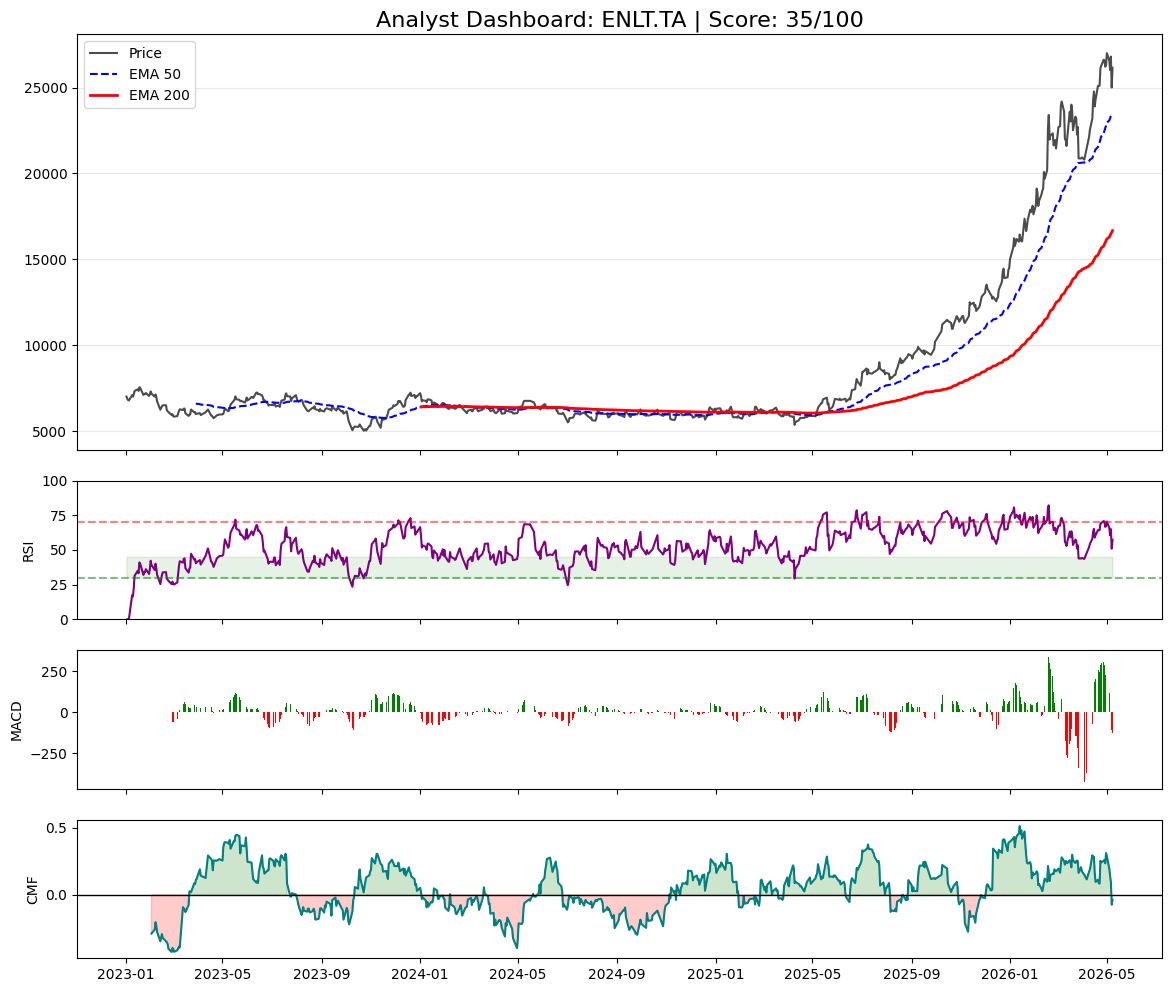

In [ ]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# הגדרות הרצה - שנה כאן את הפרמטרים
# ==========================================
TICKER_TO_ANALYZE = "ENLT.TA"   # שם המניה
BENCHMARK_INDEX = "TA35.TA"     # מדד להשוואה
START_DATE = "2023-01-01"       # תאריך התחלה (מומלץ להתחיל קרוב יותר כדי שהגרף יהיה קריא)
# ==========================================

def run_full_analysis(ticker, benchmark, start_date):
    # 1. הורדת נתונים
    df = yf.download(ticker, start=start_date, auto_adjust=True)
    bench_df = yf.download(benchmark, start=start_date, auto_adjust=True)

    if df.empty: return "No data found"
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    if isinstance(bench_df.columns, pd.MultiIndex): bench_df.columns = bench_df.columns.get_level_values(0)

    # 2. חישוב מדדים
    df['EMA200'] = ta.ema(df['Close'], length=200)
    df['EMA50'] = ta.ema(df['Close'], length=50)
    df['RSI'] = ta.rsi(df['Close'], length=14)
    macd = ta.macd(df['Close'])
    df['MACD_Hist'] = macd.iloc[:, 1]
    df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

    # חישוב ציון (לוגיקה מקוצרת לצורך התצוגה)
    last = df.iloc[-1]
    score = 0
    if last['Close'] > last['EMA200']: score += 20
    if last['EMA50'] > last['EMA200']: score += 15
    if last['CMF'] > 0: score += 10
    if last['RSI'] < 45: score += 10

    # 3. יצירת הגרפים
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1, 1]})
    plt.subplots_adjust(hspace=0.15)

    # גרף 1: מחיר וממוצעים נעים
    ax1.plot(df.index, df['Close'], label='Price', color='black', alpha=0.7)
    ax1.plot(df.index, df['EMA50'], label='EMA 50', color='blue', linestyle='--')
    ax1.plot(df.index, df['EMA200'], label='EMA 200', color='red', linewidth=2)
    ax1.set_title(f"Analyst Dashboard: {ticker} | Score: {score}/100", fontsize=16)
    ax1.legend(loc='best')
    ax1.grid(axis='y', alpha=0.3)

    # גרף 2: RSI
    ax2.plot(df.index, df['RSI'], label='RSI', color='purple')
    ax2.axhline(70, color='red', linestyle='--', alpha=0.5)  # Overbought
    ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold
    ax2.fill_between(df.index, 30, 45, color='green', alpha=0.1, label='Buy Zone')
    ax2.set_ylabel('RSI')
    ax2.set_ylim(0, 100)

    # גרף 3: MACD Histogram
    colors = ['green' if x > 0 else 'red' for x in df['MACD_Hist']]
    ax3.bar(df.index, df['MACD_Hist'], color=colors, label='MACD Hist')
    ax3.set_ylabel('MACD')

    # גרף 4: Money Flow (CMF)
    ax4.plot(df.index, df['CMF'], label='CMF', color='teal')
    ax4.axhline(0, color='black', linewidth=1)
    ax4.fill_between(df.index, df['CMF'], 0, where=(df['CMF'] > 0), color='green', alpha=0.2)
    ax4.fill_between(df.index, df['CMF'], 0, where=(df['CMF'] < 0), color='red', alpha=0.2)
    ax4.set_ylabel('CMF')

    print(f"Final Score for {ticker}: {score}")
    plt.show()

# הרצה
run_full_analysis(TICKER_TO_ANALYZE, BENCHMARK_INDEX, START_DATE)

In [2]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# הגדרות הרצה - שנה כאן את הפרמטרים
# ==========================================
TICKER_TO_ANALYZE = "ELTR.TA"
BENCHMARK_INDEX = "TA35.TA"
START_DATE = "2022-01-01"       # תאריך קרוב יחסית כדי לראות את החיצים בבירור
# ==========================================

def run_full_analysis_with_signals(ticker, benchmark, start_date):
    # 1. הורדת נתונים
    df = yf.download(ticker, start=start_date, auto_adjust=True)
    bench_df = yf.download(benchmark, start=start_date, auto_adjust=True)

    if df.empty: return "No data found"
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    if isinstance(bench_df.columns, pd.MultiIndex): bench_df.columns = bench_df.columns.get_level_values(0)

    # 2. חישוב מדדים טכניים
    df['EMA200'] = ta.ema(df['Close'], length=200)
    df['EMA50'] = ta.ema(df['Close'], length=50)
    df['RSI'] = ta.rsi(df['Close'], length=14)
    macd = ta.macd(df['Close'])
    df['MACD_Hist'] = macd.iloc[:, 1]
    df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

    # חישוב עוצמה יחסית (RS)
    rs_period = 63
    df['RS_Value'] = df['Close'].pct_change(rs_period) - bench_df['Close'].pct_change(rs_period)

    # 3. חישוב ציון יומי (Vectorized) לכל יום בגרף
    def calculate_score_row(row):
        s = 0
        if row['Close'] > row['EMA200']: s += 20
        if row['EMA50'] > row['EMA200']: s += 15
        if row['RS_Value'] > 0: s += 15
        if row['CMF'] > 0: s += 10
        if row['MACD_Hist'] > 0: s += 10
        if row['RSI'] < 45: s += 10
        return s

    df['Total_Score'] = df.apply(calculate_score_row, axis=1)

    # הגדרת איתות קנייה: ציון > 70 ומרחק מ-EMA200 קטן מ-15%
    df['Dist_EMA'] = ((df['Close'] - df['EMA200']) / df['EMA200']) * 100
    df['Buy_Signal'] = (df['Total_Score'] >= 70) & (df['Dist_EMA'] <= 15)

    # 4. יצירת הלוח הגרפי
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
    plt.subplots_adjust(hspace=0.1)

    # --- גרף 1: מחיר ואיתותים ---
    ax1.plot(df.index, df['Close'], label='Price', color='black', alpha=0.6, linewidth=1.5)
    ax1.plot(df.index, df['EMA50'], label='EMA 50', color='blue', linestyle='--', alpha=0.8)
    ax1.plot(df.index, df['EMA200'], label='EMA 200', color='red', linewidth=2)

    # סימון חיצי קנייה
    buy_dates = df[df['Buy_Signal']].index
    buy_prices = df.loc[buy_dates, 'Close']
    ax1.scatter(buy_dates, buy_prices * 0.97, marker='^', color='green', s=100, label='BUY Signal', zorder=5)

    ax1.set_title(f"Price Action & Buy Signals: {ticker}", fontsize=16)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.2)

    # --- גרף 2: ציון Analyst Dashboard ---
    ax2.plot(df.index, df['Total_Score'], label='Total Score', color='darkblue', linewidth=2)
    ax2.axhline(70, color='green', linestyle=':', label='Buy Threshold (70)')
    ax2.axhline(85, color='gold', linestyle='--', label='Strong Buy (85)')
    ax2.fill_between(df.index, df['Total_Score'], 70, where=(df['Total_Score'] >= 70), color='green', alpha=0.2)
    ax2.set_ylabel('Dashboard Score')
    ax2.set_ylim(0, 105)
    ax2.legend(loc='upper left')

    # --- גרף 3: RSI וזרימת כסף ---
    ax3.plot(df.index, df['RSI'], label='RSI', color='purple', alpha=0.8)
    ax3.axhline(30, color='gray', linestyle='--')
    ax3.axhline(70, color='gray', linestyle='--')
    ax3.fill_between(df.index, 30, 45, color='green', alpha=0.1)
    ax3.set_ylabel('RSI')
    ax3.legend(loc='upper left')

    plt.show()

    # הדפסת איתות אחרון
    last_signal = df.iloc[-1]
    print(f"Current Status for {ticker}:")
    print(f"Score: {last_signal['Total_Score']} | Price: {last_signal['Close']:.2f}")
    if last_signal['Buy_Signal']:
        print("📢 SIGNAL: BUY NOW")
    else:
        print("📢 SIGNAL: NO SIGNAL")

# הרצה
run_full_analysis_with_signals(TICKER_TO_ANALYZE, BENCHMARK_INDEX, START_DATE)

ModuleNotFoundError: No module named 'pandas_ta'

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Time

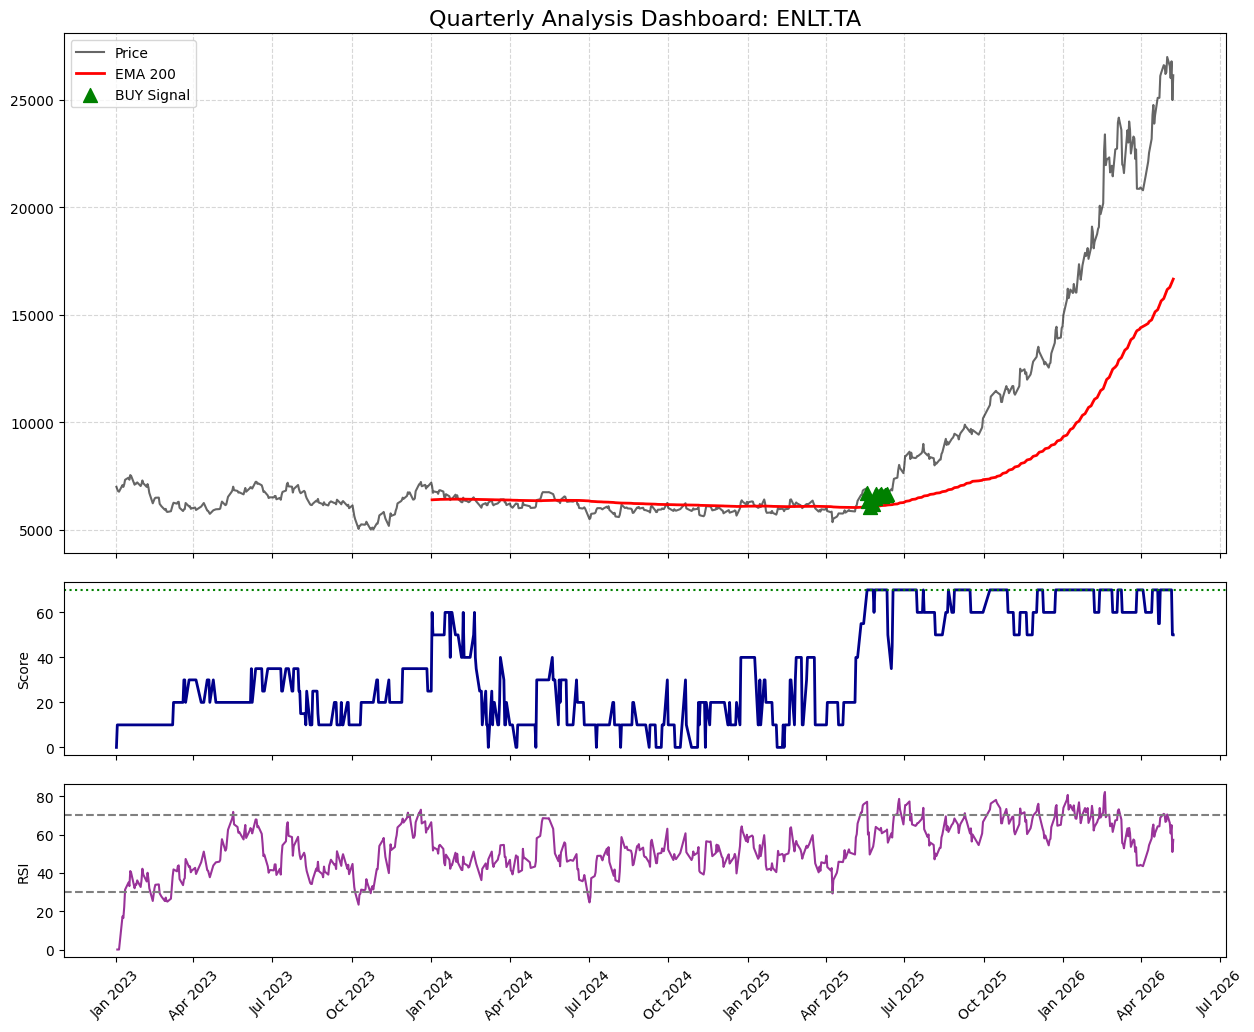

In [ ]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# הגדרות הרצה - שנה כאן את הפרמטרים
# ==========================================
TICKER_TO_ANALYZE = "ENLT.TA"
BENCHMARK_INDEX = "TA35.TA"
START_DATE = "2023-01-01"  # טווח ארוך יותר כדי לראות את החלוקה לרבעונים
# ==========================================

def run_full_analysis_with_quarterly_axis(ticker, benchmark, start_date):
    # 1. הורדת נתונים
    df = yf.download(ticker, start=start_date, auto_adjust=True)
    bench_df = yf.download(benchmark, start=start_date, auto_adjust=True)

    if df.empty: return "No data found"
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    if isinstance(bench_df.columns, pd.MultiIndex): bench_df.columns = bench_df.columns.get_level_values(0)

    # 2. חישוב מדדים טכניים
    df['EMA200'] = ta.ema(df['Close'], length=200)
    df['EMA50'] = ta.ema(df['Close'], length=50)
    df['RSI'] = ta.rsi(df['Close'], length=14)
    macd = ta.macd(df['Close'])
    df['MACD_Hist'] = macd.iloc[:, 1]
    df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

    rs_period = 63
    df['RS_Value'] = df['Close'].pct_change(rs_period) - bench_df['Close'].pct_change(rs_period)

    # 3. חישוב ציון ואיתותים
    def calculate_score_row(row):
        s = 0
        if row['Close'] > row['EMA200']: s += 20
        if row['EMA50'] > row['EMA200']: s += 15
        if row['RS_Value'] > 0: s += 15
        if row['CMF'] > 0: s += 10
        if row['MACD_Hist'] > 0: s += 10
        if row['RSI'] < 45: s += 10
        return s

    df['Total_Score'] = df.apply(calculate_score_row, axis=1)
    df['Dist_EMA'] = ((df['Close'] - df['EMA200']) / df['EMA200']) * 100
    df['Buy_Signal'] = (df['Total_Score'] >= 70) & (df['Dist_EMA'] <= 15)

    # 4. יצירת הלוח הגרפי
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
    plt.subplots_adjust(hspace=0.1)

    # עיצוב ציר X לרבעונים
    locator = mdates.MonthLocator(bymonth=[1, 4, 7, 10]) # ינואר, אפריל, יולי, אוקטובר
    fmt = mdates.DateFormatter('%b %Y') # פורמט: חודש ושנה

    # --- גרף 1: מחיר ואיתותים ---
    ax1.plot(df.index, df['Close'], label='Price', color='black', alpha=0.6, linewidth=1.5)
    ax1.plot(df.index, df['EMA200'], label='EMA 200', color='red', linewidth=2)

    # סימון חיצי קנייה
    buy_dates = df[df['Buy_Signal']].index
    buy_prices = df.loc[buy_dates, 'Close']
    ax1.scatter(buy_dates, buy_prices * 0.97, marker='^', color='green', s=100, label='BUY Signal', zorder=5)

    ax1.set_title(f"Quarterly Analysis Dashboard: {ticker}", fontsize=16)
    ax1.xaxis.set_major_locator(locator)
    ax1.xaxis.set_major_formatter(fmt)
    ax1.legend(loc='upper left')
    ax1.grid(True, which='major', axis='both', linestyle='--', alpha=0.5)

    # --- גרף 2: ציון ---
    ax2.plot(df.index, df['Total_Score'], label='Dashboard Score', color='darkblue', linewidth=2)
    ax2.axhline(70, color='green', linestyle=':', label='Threshold (70)')
    ax2.fill_between(df.index, df['Total_Score'], 70, where=(df['Total_Score'] >= 70), color='green', alpha=0.2)
    ax2.set_ylabel('Score')

    # --- גרף 3: RSI ---
    ax3.plot(df.index, df['RSI'], label='RSI', color='purple', alpha=0.8)
    ax3.axhline(30, color='gray', linestyle='--')
    ax3.axhline(70, color='gray', linestyle='--')
    ax3.set_ylabel('RSI')

    # סיבוב התאריכים לשיפור הקריאות
    plt.xticks(rotation=45)

    plt.show()

# הרצה
run_full_analysis_with_quarterly_axis(TICKER_TO_ANALYZE, BENCHMARK_INDEX, START_DATE)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


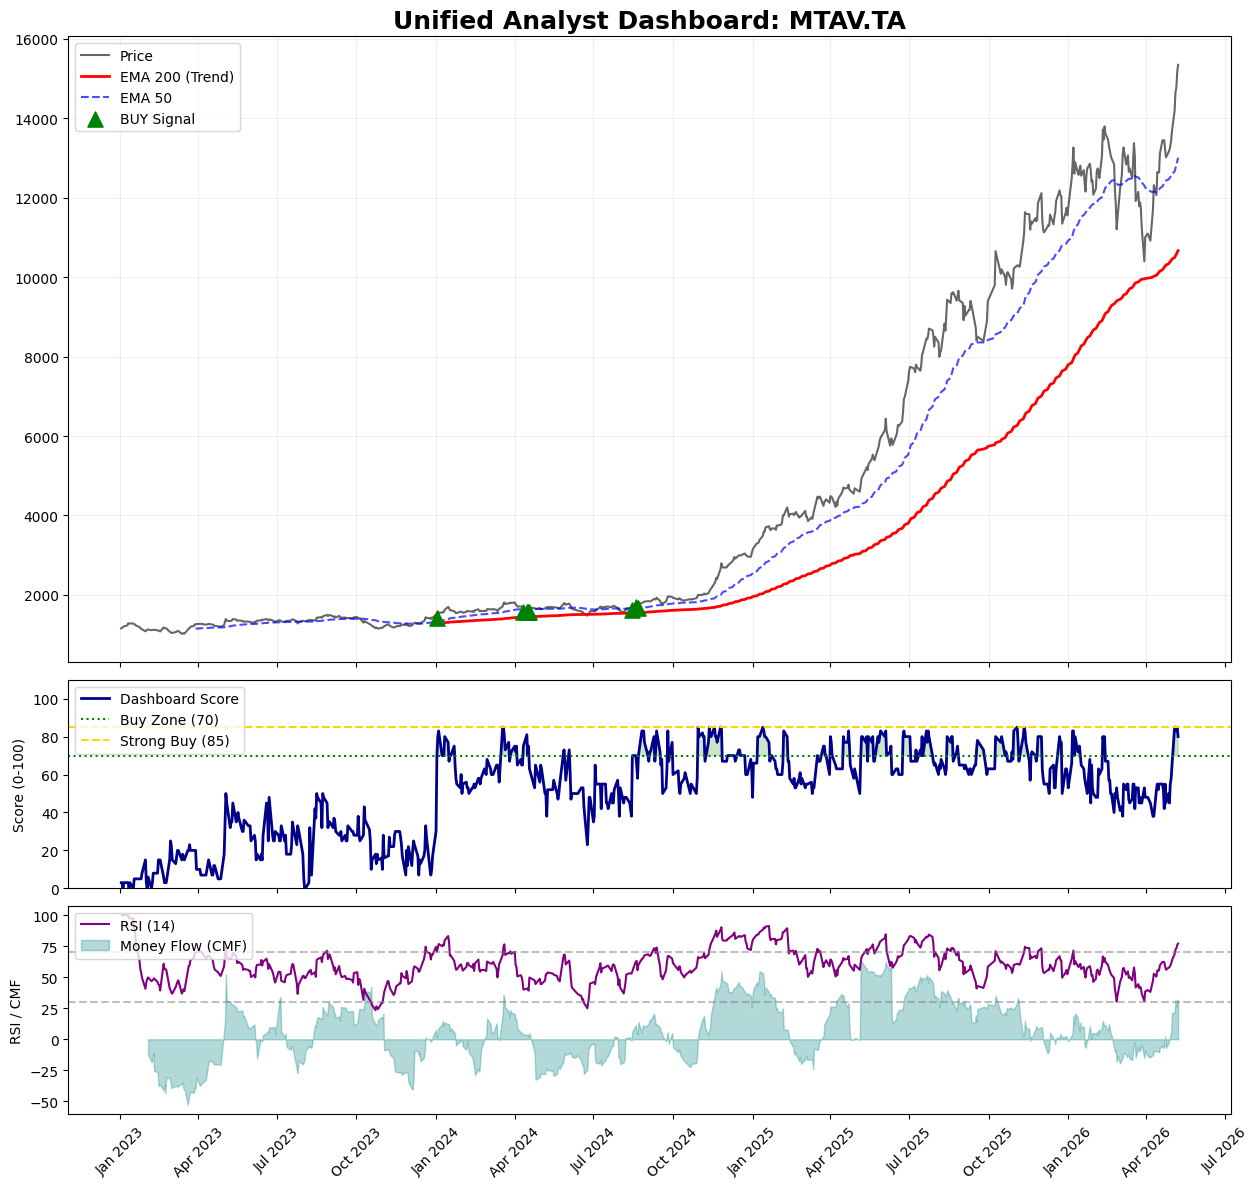


FINAL REPORT FOR MTAV.TA
Current Score: 80.0/100
RSI: 77.12 | CMF: 0.31
Dist from EMA200: 43.84%
SIGNAL STATUS: ⏳ WAIT / NEUTRAL


In [ ]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# הגדרות הרצה - שנה כאן את הפרמטרים
# ==========================================
TICKER_TO_ANALYZE = "MTAV.TA"   # שם המניה
BENCHMARK_INDEX = "TA35.TA"     # מדד להשוואה
START_DATE = "2023-01-01"       # תאריך התחלה לניתוח
# ==========================================

def run_unified_analyst_dashboard(ticker, benchmark, start_date):
    # 1. הורדת נתונים
    print(f"Downloading data for {ticker} vs {benchmark}...")
    df = yf.download(ticker, start=start_date, auto_adjust=True)
    bench_df = yf.download(benchmark, start=start_date, auto_adjust=True)

    if df.empty or len(df) < 200:
        return "שגיאה: אין מספיק נתונים היסטוריים לחישוב ממוצע 200"

    # ניקוי מבנה הנתונים
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    if isinstance(bench_df.columns, pd.MultiIndex): bench_df.columns = bench_df.columns.get_level_values(0)
    df = df.copy()

    # 2. חישוב אינדיקטורים (Core Logic)
    df['EMA200'] = ta.ema(df['Close'], length=200)
    df['EMA50'] = ta.ema(df['Close'], length=50)
    df['RSI'] = ta.rsi(df['Close'], length=14)

    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['MACD_Hist'] = macd.iloc[:, 1]
    df['MACD_Momentum'] = (df['MACD_Hist'] > 0) & (df['MACD_Hist'] > df['MACD_Hist'].shift(1))

    df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

    rs_period = 63
    df['Ticker_Ret'] = df['Close'].pct_change(rs_period)
    bench_ret = bench_df['Close'].pct_change(rs_period)
    df['RS_Value'] = df['Ticker_Ret'] - bench_ret

    df['RVOL'] = df['Volume'] / df['Volume'].rolling(10).mean()
    df['Last_Low'] = df['Low'].rolling(window=5).min()
    df['Near_Support'] = (df['Close'] <= df['Last_Low'] * 1.025) & (df['Close'] >= df['Last_Low'] * 0.98)
    df['Inst_Absorption'] = (df['RVOL'] > 1.5) & (df['Close'] > (df['Low'] + (df['High'] - df['Low']) * 0.66))

    # 3. חישוב הציון המשוקלל (Total Score - Max 100)
    def calculate_daily_score(row):
        score = 0.0
        if row['Close'] > row['EMA200']: score += 20
        if row['EMA50'] > row['EMA200']: score += 15
        if row['RS_Value'] > 0: score += 15
        if row['CMF'] > 0: score += 10
        if row['MACD_Momentum']: score += 10
        if 30 <= row['RSI'] <= 45: score += 10  # RSI Buy Zone
        if row['MACD_Hist'] > 0: score += 7     # MACD Trend
        if row['Near_Support']: score += 5
        if row['Close'] > row['Open']: score += 3 # Bullish Candle
        if row['RVOL'] > 1.2: score += 3
        if row['Inst_Absorption']: score += 2
        return score

    df['Total_Score'] = df.apply(calculate_daily_score, axis=1)

    # תנאי איתות (Setup Ready)
    df['Dist_EMA'] = ((df['Close'] - df['EMA200']) / df['EMA200']) * 100
    df['Buy_Signal'] = (df['Total_Score'] >= 70) & (df['Dist_EMA'] <= 15)

    # 4. תצוגה גרפית מאוחדת
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 14), sharex=True,
                                       gridspec_kw={'height_ratios': [3, 1, 1]})
    plt.subplots_adjust(hspace=0.05)

    # הגדרת ציר X רבעוני
    locator = mdates.MonthLocator(bymonth=[1, 4, 7, 10])
    fmt = mdates.DateFormatter('%b %Y')

    # גרף 1: מחיר, ממוצעים ואיתותים
    ax1.plot(df.index, df['Close'], label='Price', color='black', alpha=0.6)
    ax1.plot(df.index, df['EMA200'], label='EMA 200 (Trend)', color='red', linewidth=2)
    ax1.plot(df.index, df['EMA50'], label='EMA 50', color='blue', linestyle='--', alpha=0.7)

    # סימון חיצי קנייה
    buys = df[df['Buy_Signal']]
    ax1.scatter(buys.index, buys['Close'] * 0.96, marker='^', color='green', s=120, label='BUY Signal', zorder=5)

    ax1.set_title(f"Unified Analyst Dashboard: {ticker}", fontsize=18, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.2)

    # גרף 2: ציון ה-Dashboard לאורך זמן
    ax2.plot(df.index, df['Total_Score'], label='Dashboard Score', color='darkblue', linewidth=2)
    ax2.axhline(70, color='green', linestyle=':', label='Buy Zone (70)')
    ax2.axhline(85, color='gold', linestyle='--', label='Strong Buy (85)')
    ax2.fill_between(df.index, df['Total_Score'], 70, where=(df['Total_Score'] >= 70), color='green', alpha=0.2)
    ax2.set_ylabel('Score (0-100)')
    ax2.set_ylim(0, 110)
    ax2.legend(loc='upper left')

    # גרף 3: RSI ו-Money Flow (CMF)
    ax3.plot(df.index, df['RSI'], label='RSI (14)', color='purple')
    ax3.fill_between(df.index, df['CMF']*100, 0, color='teal', alpha=0.3, label='Money Flow (CMF)')
    ax3.axhline(30, color='gray', linestyle='--', alpha=0.5)
    ax3.axhline(70, color='gray', linestyle='--', alpha=0.5)
    ax3.set_ylabel('RSI / CMF')
    ax3.legend(loc='upper left')

    ax3.xaxis.set_major_locator(locator)
    ax3.xaxis.set_major_formatter(fmt)
    plt.xticks(rotation=45)

    plt.show()

    # 5. דוח מילולי לסיכום (השורה האחרונה)
    last = df.iloc[-1]
    print(f"\n" + "="*30)
    print(f"FINAL REPORT FOR {ticker}")
    print(f"="*30)
    print(f"Current Score: {last['Total_Score']}/100")
    print(f"RSI: {last['RSI']:.2f} | CMF: {last['CMF']:.2f}")
    print(f"Dist from EMA200: {last['Dist_EMA']:.2f}%")

    if last['Buy_Signal']:
        status = "💎 STRONG BUY 💎" if last['Total_Score'] >= 85 else "✅ READY / BUY"
    else:
        status = "⏳ WAIT / NEUTRAL"

    print(f"SIGNAL STATUS: {status}")
    print("="*30)

# הרצה של הקוד המאוחד
run_unified_analyst_dashboard(TICKER_TO_ANALYZE, BENCHMARK_INDEX, START_DATE)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


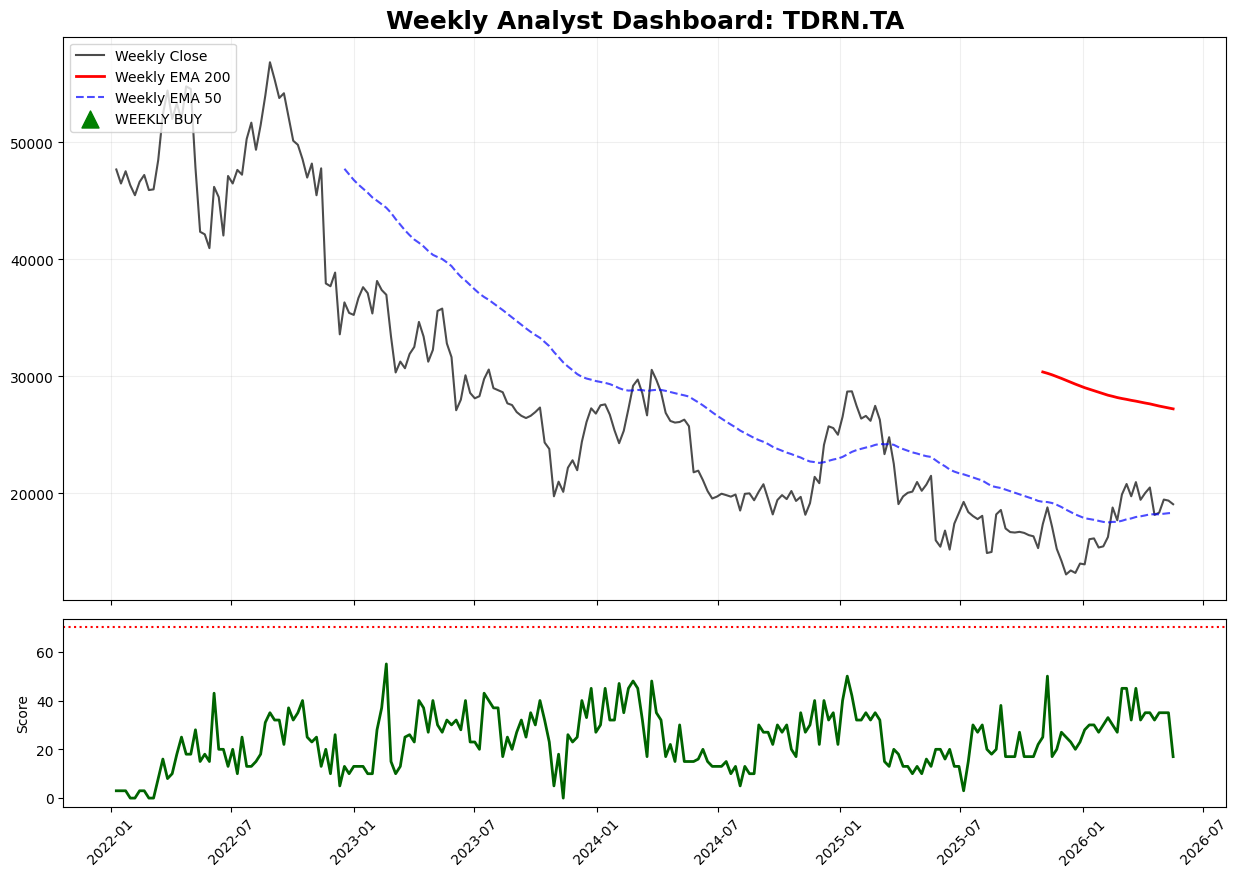


WEEKLY SUMMARY FOR TDRN.TA:
Score: 17.0/100 | RSI: 53.40 | CMF: 0.34
Signal: HOLD / WAIT


In [7]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# הגדרות הרצה - שנה כאן את הפרמטרים
# ==========================================
TICKER_TO_ANALYZE = "TDRN.TA"   # שם המניה
BENCHMARK_INDEX = "TA35.TA"     # מדד להשוואה
START_DATE = "2022-01-01"       # בגרף שבועי מומלץ לקחת טווח רחב יותר (לפחות שנתיים-שלוש)
# ==========================================

def run_weekly_analyst_dashboard(ticker, benchmark, start_date):
    # 1. הורדת נתונים יומיים
    print(f"Downloading daily data for {ticker}...")
    df_daily = yf.download(ticker, start=start_date, auto_adjust=True)
    bench_daily = yf.download(benchmark, start=start_date, auto_adjust=True)

    if df_daily.empty: return "No data found"

    # ניקוי MultiIndex
    if isinstance(df_daily.columns, pd.MultiIndex): df_daily.columns = df_daily.columns.get_level_values(0)
    if isinstance(bench_daily.columns, pd.MultiIndex): bench_daily.columns = bench_daily.columns.get_level_values(0)

    # 2. המרה לנתונים שבועיים (Resampling)
    # אנו מאחדים את הנתונים לסוף כל שבוע (W-FRI)
    logic = {'Open'  : 'first',
             'High'  : 'max',
             'Low'   : 'min',
             'Close' : 'last',
             'Volume': 'sum'}

    df = df_daily.resample('W').apply(logic)
    bench_df = bench_daily.resample('W').apply({'Close': 'last'})

    # הסרת שורות ריקות במידה ויש שבועות ללא מסחר
    df.dropna(inplace=True)
    bench_df.dropna(inplace=True)

    # 3. חישוב אינדיקטורים על בסיס שבועי
    df['EMA200'] = ta.ema(df['Close'], length=200)
    df['EMA50'] = ta.ema(df['Close'], length=50)
    df['RSI'] = ta.rsi(df['Close'], length=14)

    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['MACD_Hist'] = macd.iloc[:, 1]
    df['MACD_Momentum'] = (df['MACD_Hist'] > 0) & (df['MACD_Hist'] > df['MACD_Hist'].shift(1))

    df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

    # עוצמה יחסית שבועית (מול המדד בשבועות)
    rs_period = 13 # 13 שבועות שקולים לרבעון (במקום 63 ימים)
    df['Ticker_Ret'] = df['Close'].pct_change(rs_period)
    bench_ret = bench_df['Close'].pct_change(rs_period)
    df['RS_Value'] = df['Ticker_Ret'] - bench_ret

    df['RVOL'] = df['Volume'] / df['Volume'].rolling(10).mean()
    df['Last_Low'] = df['Low'].rolling(window=5).min()
    df['Near_Support'] = (df['Close'] <= df['Last_Low'] * 1.025) & (df['Close'] >= df['Last_Low'] * 0.98)

    # 4. אלגוריתם הניקוד (זהה למקור, מותאם לשבועי)
    def calculate_weekly_score(row):
        score = 0.0
        if row['Close'] > row['EMA200']: score += 20
        if row['EMA50'] > row['EMA200']: score += 15
        if row['RS_Value'] > 0: score += 15
        if row['CMF'] > 0: score += 10
        if row['MACD_Momentum']: score += 10
        if 30 <= row['RSI'] <= 45: score += 10
        if row['MACD_Hist'] > 0: score += 7
        if row['Near_Support']: score += 5
        if row['Close'] > row['Open']: score += 3 # שבוע חיובי
        if row['RVOL'] > 1.2: score += 3
        if row['RVOL'] > 1.5: score += 2 # ספיגה מוסדית שבועית
        return score

    df['Total_Score'] = df.apply(calculate_weekly_score, axis=1)

    # תנאי איתות
    df['Dist_EMA'] = ((df['Close'] - df['EMA200']) / df['EMA200']) * 100
    df['Buy_Signal'] = (df['Total_Score'] >= 70) & (df['Dist_EMA'] <= 15)

    # 5. תצוגה גרפית
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(hspace=0.05)

    # ציר X רבעוני
    ax1.plot(df.index, df['Close'], label='Weekly Close', color='black', alpha=0.7)
    ax1.plot(df.index, df['EMA200'], label='Weekly EMA 200', color='red', linewidth=2)
    ax1.plot(df.index, df['EMA50'], label='Weekly EMA 50', color='blue', linestyle='--', alpha=0.7)

    # סימון איתותים שבועיים
    buys = df[df['Buy_Signal']]
    ax1.scatter(buys.index, buys['Close'] * 0.95, marker='^', color='green', s=150, label='WEEKLY BUY', zorder=5)

    ax1.set_title(f"Weekly Analyst Dashboard: {ticker}", fontsize=18, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.2)

    # גרף הציון
    ax2.plot(df.index, df['Total_Score'], label='Weekly Score', color='darkgreen', linewidth=2)
    ax2.axhline(70, color='red', linestyle=':')
    ax2.fill_between(df.index, df['Total_Score'], 70, where=(df['Total_Score'] >= 70), color='green', alpha=0.3)
    ax2.set_ylabel('Score')

    plt.xticks(rotation=45)
    plt.show()

    # דוח סופי
    last = df.iloc[-1]
    print(f"\nWEEKLY SUMMARY FOR {ticker}:")
    print(f"Score: {last['Total_Score']}/100 | RSI: {last['RSI']:.2f} | CMF: {last['CMF']:.2f}")
    print(f"Signal: {'💎 WEEKLY BUY 💎' if last['Buy_Signal'] else 'HOLD / WAIT'}")

# הרצה
run_weekly_analyst_dashboard(TICKER_TO_ANALYZE, BENCHMARK_INDEX, START_DATE)

In [3]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np

# ==========================================
# הגדרות הסורק (Screener)
# ==========================================
PRINT_THRESHOLD = 70            # סף הניקוד להדפסה (רק מעל 70 יודפס)
BENCHMARK_INDEX = "TA35.TA"      # מדד להשוואה
START_DATE = "2024-01-01"        # תאריך התחלה (נדרש מספיק וותק לממוצע 200 שבועי)

# רשימת המניות לסריקה
assets = [
    "AURA.TA", "OPCE.TA", "ORA.TA", "ICL.TA", "ARPT.TA", "INRM.TA",
    "ESLT.TA", "ALHE.TA", "ELTR.TA", "ECP.TA", "ELWS.TA", "AMOT.TA",
    "ENLT.TA", "ENRG.TA", "ORL.TA", "BEZQ.TA", "BIG.TA", "GCTY.TA",
    "GNRS.TA", "GVYM.TA", "GILT.TA", "DLEKG.TA", "DELT.TA", "DIMRI.TA",
    "DNL.TA", "ILDC.TA", "HARL.TA", "ISRA.TA", "LUMI.TA", "LAHAV.TA",
    "LAPD.TA", "MZTF.TA", "MTRX.TA", "MTAV.TA", "MTRN.TA", "DIFI.TA",
    "MLSR.TA", "ISHS.TA", "NAWI.TA", "NVMI.TA", "NOFR.TA", "NWMD.TA",
    "NICE.TA", "PTNR.TA", "CEL.TA", "AZRG.TA", "POLI.TA", "FOX.TA",
    "PZBA.TA", "PRTC.TA", "FTAL.TA", "RIT1.TA", "RMLI.TA", "RATP.TA",
    "SHBA.TA", "SAE.TA", "STRS.TA", "SPEN.TA", "TDRN.TA", "TRPZ.TA",
    "AAPL", "XLK", "XLF", "XLV", "XLY", "XLP", "XLI", "XLC", "XLE", "XLU", "XLB", "XLRE"
]

def get_weekly_score(ticker, bench_df):
    try:
        # הורדת נתונים יומיים והמרה לשבועי
        raw = yf.download(ticker, start=START_DATE, auto_adjust=True, progress=False)
        if raw.empty or len(raw) < 200: return None

        if isinstance(raw.columns, pd.MultiIndex): raw.columns = raw.columns.get_level_values(0)

        logic = {'Open':'first', 'High':'max', 'Low':'min', 'Close':'last', 'Volume':'sum'}
        df = raw.resample('W').apply(logic).dropna()

        # חישוב אינדיקטורים שבועיים
        df['EMA200'] = ta.ema(df['Close'], length=200)
        df['EMA50'] = ta.ema(df['Close'], length=50)
        df['RSI'] = ta.rsi(df['Close'], length=14)
        macd = ta.macd(df['Close'])
        df['MACD_Hist'] = macd.iloc[:, 1]
        df['MACD_Mom'] = (df['MACD_Hist'] > 0) & (df['MACD_Hist'] > df['MACD_Hist'].shift(1))
        df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

        # עוצמה יחסית (RS) שבועי
        rs_period = 13
        ticker_ret = df['Close'].pct_change(rs_period)
        bench_ret = bench_df['Close'].pct_change(rs_period)
        df['RS_Value'] = ticker_ret - bench_ret

        df['RVOL'] = df['Volume'] / df['Volume'].rolling(10).mean()
        df['Last_Low'] = df['Low'].rolling(window=5).min()
        df['Near_Support'] = (df['Close'] <= df['Last_Low'] * 1.025) & (df['Close'] >= df['Last_Low'] * 0.98)

        # לוגיקת הניקוד
        last = df.iloc[-1]
        score = 0.0
        if last['Close'] > last['EMA200']: score += 20
        if last['EMA50'] > last['EMA200']: score += 15
        if last['RS_Value'] > 0: score += 15
        if last['CMF'] > 0: score += 10
        if last['MACD_Mom']: score += 10
        if 30 <= last['RSI'] <= 45: score += 10
        if last['MACD_Hist'] > 0: score += 7
        if last['Near_Support']: score += 5
        if last['Close'] > last['Open']: score += 3
        if last['RVOL'] > 1.2: score += 3
        if last['RVOL'] > 1.5: score += 2

        dist_ema = ((last['Close'] - last['EMA200']) / last['EMA200']) * 100

        return {
            "Ticker": ticker,
            "Score": score,
            "RSI": round(last['RSI'], 2),
            "CMF": round(last['CMF'], 2),
            "Dist_EMA200": round(dist_ema, 2),
            "Status": "STRONG BUY" if score >= 85 and dist_ema <= 15 else "BUY" if score >= 70 and dist_ema <= 15 else "WAIT"
        }
    except:
        return None

# --- הרצה מרכזית ---
print(f"Starting Weekly Scanner (Threshold: {PRINT_THRESHOLD})...")
print("-" * 65)
print(f"{'Ticker':<12} | {'Score':<6} | {'RSI':<6} | {'CMF':<6} | {'Status':<12}")
print("-" * 65)

# הורדת נתוני מדד הייחוס פעם אחת
bench_raw = yf.download(BENCHMARK_INDEX, start=START_DATE, auto_adjust=True, progress=False)
if isinstance(bench_raw.columns, pd.MultiIndex): bench_raw.columns = bench_raw.columns.get_level_values(0)
bench_weekly = bench_raw.resample('W').apply({'Close': 'last'}).dropna()

# לולאת סריקה
passed_assets = []
for symbol in assets:
    res = get_weekly_score(symbol, bench_weekly)
    if res and res['Score'] >= PRINT_THRESHOLD:
        passed_assets.append(res)
        print(f"{res['Ticker']:<12} | {res['Score']:<6.0f} | {res['RSI']:<6.1f} | {res['CMF']:<6.2f} | {res['Status']:<12}")

print("-" * 65)
print(f"Scan complete. Found {len(passed_assets)} assets above threshold.")

Starting Weekly Scanner (Threshold: 70)...
-----------------------------------------------------------------
Ticker       | Score  | RSI    | CMF    | Status      
-----------------------------------------------------------------


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['GCTY.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DELT.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DNL.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ISHS.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PZBA.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['RATP.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SHBA.TA']: possibly delisted; no timezone found


-----------------------------------------------------------------
Scan complete. Found 0 assets above threshold.


In [ ]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np

# ==========================================
# הגדרות הסורק (Screener)
# ==========================================
PRINT_THRESHOLD = 70            # סף הניקוד להדפסה (רק מעל 70 יודפס)
BENCHMARK_INDEX = "TA35.TA"      # מדד להשוואה
START_DATE = "2022-01-01"        # תאריך התחלה (נדרש מספיק וותק לממוצע 200 שבועי)

# רשימת המניות לסריקה
assets = [
    "AURA.TA", "OPCE.TA", "ORA.TA", "ICL.TA", "ARPT.TA", "INRM.TA",
    "ESLT.TA", "ALHE.TA", "ELTR.TA", "ECP.TA", "ELWS.TA", "AMOT.TA",
    "ENLT.TA", "ENRG.TA", "ORL.TA", "BEZQ.TA", "BIG.TA", "GCTY.TA",
    "GNRS.TA", "GVYM.TA", "GILT.TA", "DLEKG.TA", "DELT.TA", "DIMRI.TA",
    "DNL.TA", "ILDC.TA", "HARL.TA", "ISRA.TA", "LUMI.TA", "LAHAV.TA",
    "LAPD.TA", "MZTF.TA", "MTRX.TA", "MTAV.TA", "MTRN.TA", "DIFI.TA",
    "MLSR.TA", "ISHS.TA", "NAWI.TA", "NVMI.TA", "NOFR.TA", "NWMD.TA",
    "NICE.TA", "PTNR.TA", "CEL.TA", "AZRG.TA", "POLI.TA", "FOX.TA",
    "PZBA.TA", "PRTC.TA", "FTAL.TA", "RIT1.TA", "RMLI.TA", "RATP.TA",
    "SHBA.TA", "SAE.TA", "STRS.TA", "SPEN.TA", "TDRN.TA", "TRPZ.TA",
    "AAPL", "XLK", "XLF", "XLV", "XLY", "XLP", "XLI", "XLC", "XLE", "XLU", "XLB", "XLRE"
]

def get_weekly_score(ticker, bench_df):
    try:
        # הורדת נתונים יומיים והמרה לשבועי
        raw = yf.download(ticker, start=START_DATE, auto_adjust=True, progress=False)
        if raw.empty or len(raw) < 200: return None

        if isinstance(raw.columns, pd.MultiIndex): raw.columns = raw.columns.get_level_values(0)

        logic = {'Open':'first', 'High':'max', 'Low':'min', 'Close':'last', 'Volume':'sum'}
        df = raw.resample('W').apply(logic).dropna()

        # חישוב אינדיקטורים שבועיים
        df['EMA200'] = ta.ema(df['Close'], length=200)
        df['EMA50'] = ta.ema(df['Close'], length=50)
        df['RSI'] = ta.rsi(df['Close'], length=14)
        macd = ta.macd(df['Close'])
        df['MACD_Hist'] = macd.iloc[:, 1]
        df['MACD_Mom'] = (df['MACD_Hist'] > 0) & (df['MACD_Hist'] > df['MACD_Hist'].shift(1))
        df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

        # עוצמה יחסית (RS) שבועי
        rs_period = 13
        ticker_ret = df['Close'].pct_change(rs_period)
        bench_ret = bench_df['Close'].pct_change(rs_period)
        df['RS_Value'] = ticker_ret - bench_ret

        df['RVOL'] = df['Volume'] / df['Volume'].rolling(10).mean()
        df['Last_Low'] = df['Low'].rolling(window=5).min()
        df['Near_Support'] = (df['Close'] <= df['Last_Low'] * 1.025) & (df['Close'] >= df['Last_Low'] * 0.98)

        # לוגיקת הניקוד
        last = df.iloc[-1]
        score = 0.0
        if last['Close'] > last['EMA200']: score += 20
        if last['EMA50'] > last['EMA200']: score += 15
        if last['RS_Value'] > 0: score += 15
        if last['CMF'] > 0: score += 10
        if last['MACD_Mom']: score += 10
        if 30 <= last['RSI'] <= 45: score += 10
        if last['MACD_Hist'] > 0: score += 7
        if last['Near_Support']: score += 5
        if last['Close'] > last['Open']: score += 3
        if last['RVOL'] > 1.2: score += 3
        if last['RVOL'] > 1.5: score += 2

        dist_ema = ((last['Close'] - last['EMA200']) / last['EMA200']) * 100

        return {
            "Ticker": ticker,
            "Score": score,
            "RSI": round(last['RSI'], 2),
            "CMF": round(last['CMF'], 2),
            "Dist_EMA200": round(dist_ema, 2),
            "Status": "STRONG BUY" if score >= 85 and dist_ema <= 15 else "BUY" if score >= 70 and dist_ema <= 15 else "WAIT"
        }
    except:
        return None

# --- הרצה מרכזית ---
print(f"Starting Weekly Scanner (Threshold: {PRINT_THRESHOLD})...")
print("-" * 65)
print(f"{'Ticker':<12} | {'Score':<6} | {'RSI':<6} | {'CMF':<6} | {'Status':<12}")
print("-" * 65)

# הורדת נתוני מדד הייחוס פעם אחת
bench_raw = yf.download(BENCHMARK_INDEX, start=START_DATE, auto_adjust=True, progress=False)
if isinstance(bench_raw.columns, pd.MultiIndex): bench_raw.columns = bench_raw.columns.get_level_values(0)
bench_weekly = bench_raw.resample('W').apply({'Close': 'last'}).dropna()

# לולאת סריקה
passed_assets = []
for symbol in assets:
    res = get_weekly_score(symbol, bench_weekly)
    if res and res['Score'] >= PRINT_THRESHOLD:
        passed_assets.append(res)
        print(f"{res['Ticker']:<12} | {res['Score']:<6.0f} | {res['RSI']:<6.1f} | {res['CMF']:<6.2f} | {res['Status']:<12}")

print("-" * 65)
print(f"Scan complete. Found {len(passed_assets)} assets above threshold.")

Starting Weekly Scanner (Threshold: 70)...
-----------------------------------------------------------------
Ticker       | Score  | RSI    | CMF    | Status      
-----------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


AURA.TA      | 70     | 54.5   | 0.05   | WAIT        


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


OPCE.TA      | 72     | 75.0   | 0.15   | WAIT        


...

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrap

XLK          | 80     | 77.7   | 0.02   | WAIT        


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrap

-----------------------------------------------------------------
Scan complete. Found 21 assets above threshold.


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


In [ ]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np
import warnings

# השתקת הודעות מערכת ורעש מהקונסול
warnings.filterwarnings('ignore')

# ==========================================
# הגדרות הסורק (Screener)
# ==========================================
PRINT_THRESHOLD = 70            # סף הניקוד להדפסה
BENCHMARK_INDEX = "TA35.TA"      # מדד להשוואה
START_DATE = "2022-01-01"

assets = [
    "AURA.TA", "OPCE.TA", "ORA.TA", "ICL.TA", "ARPT.TA", "INRM.TA",
    "ESLT.TA", "ALHE.TA", "ELTR.TA", "ECP.TA", "ELWS.TA", "AMOT.TA",
    "ENLT.TA", "ENRG.TA", "ORL.TA", "BEZQ.TA", "BIG.TA", "GCTY.TA",
    "GNRS.TA", "GVYM.TA", "GILT.TA", "DLEKG.TA", "DELT.TA", "DIMRI.TA",
    "DNL.TA", "ILDC.TA", "HARL.TA", "ISRA.TA", "LUMI.TA", "LAHAV.TA",
    "LAPD.TA", "MZTF.TA", "MTRX.TA", "MTAV.TA", "MTRN.TA", "DIFI.TA",
    "MLSR.TA", "ISHS.TA", "NAWI.TA", "NVMI.TA", "NOFR.TA", "NWMD.TA",
    "NICE.TA", "PTNR.TA", "CEL.TA", "AZRG.TA", "POLI.TA", "FOX.TA",
    "PZBA.TA", "PRTC.TA", "FTAL.TA", "RIT1.TA", "RMLI.TA", "RATP.TA",
    "SHBA.TA", "SAE.TA", "STRS.TA", "SPEN.TA", "TDRN.TA", "TRPZ.TA",
    "AAPL", "XLK", "XLF", "XLV", "XLY", "XLP", "XLI", "XLC", "XLE", "XLU", "XLB", "XLRE"
]

def get_weekly_score(ticker, bench_df):
    try:
        raw = yf.download(ticker, start=START_DATE, auto_adjust=True, progress=False, show_errors=False)
        if raw.empty or len(raw) < 200: return None
        if isinstance(raw.columns, pd.MultiIndex): raw.columns = raw.columns.get_level_values(0)

        logic = {'Open':'first', 'High':'max', 'Low':'min', 'Close':'last', 'Volume':'sum'}
        df = raw.resample('W').apply(logic).dropna()

        df['EMA200'] = ta.ema(df['Close'], length=200)
        df['EMA50'] = ta.ema(df['Close'], length=50)
        df['RSI'] = ta.rsi(df['Close'], length=14)
        macd = ta.macd(df['Close'])
        df['MACD_Hist'] = macd.iloc[:, 1]
        df['MACD_Mom'] = (df['MACD_Hist'] > 0) & (df['MACD_Hist'] > df['MACD_Hist'].shift(1))
        df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

        rs_period = 13
        ticker_ret = df['Close'].pct_change(rs_period)
        bench_ret = bench_df['Close'].pct_change(rs_period)
        df['RS_Value'] = ticker_ret - bench_ret

        df['RVOL'] = df['Volume'] / df['Volume'].rolling(10).mean()
        df['Last_Low'] = df['Low'].rolling(window=5).min()
        df['Near_Support'] = (df['Close'] <= df['Last_Low'] * 1.025) & (df['Close'] >= df['Last_Low'] * 0.98)

        last = df.iloc[-1]
        score = 0.0
        if last['Close'] > last['EMA200']: score += 20
        if last['EMA50'] > last['EMA200']: score += 15
        if last['RS_Value'] > 0: score += 15
        if last['CMF'] > 0: score += 10
        if last['MACD_Mom']: score += 10
        if 30 <= last['RSI'] <= 45: score += 10
        if last['MACD_Hist'] > 0: score += 7
        if last['Near_Support']: score += 5
        if last['Close'] > last['Open']: score += 3
        if last['RVOL'] > 1.2: score += 3
        if last['RVOL'] > 1.5: score += 2

        dist_ema = ((last['Close'] - last['EMA200']) / last['EMA200']) * 100

        return {
            "Ticker": ticker,
            "Score": int(score),
            "RSI": round(last['RSI'], 1),
            "CMF": round(last['CMF'], 2),
            "Dist_EMA200": f"{round(dist_ema, 1)}%",
            "Status": "💎 STRONG" if score >= 85 and dist_ema <= 15 else "✅ BUY" if score >= 70 and dist_ema <= 15 else "⏳ WAIT"
        }
    except:
        return None

# --- הרצה מרכזית ---
print("🚀 Starting Weekly Scanner... Please wait.")

bench_raw = yf.download(BENCHMARK_INDEX, start=START_DATE, auto_adjust=True, progress=False, show_errors=False)
if isinstance(bench_raw.columns, pd.MultiIndex): bench_raw.columns = bench_raw.columns.get_level_values(0)
bench_weekly = bench_raw.resample('W').apply({'Close': 'last'}).dropna()

results_list = []
for symbol in assets:
    res = get_weekly_score(symbol, bench_weekly)
    if res and res['Score'] >= PRINT_THRESHOLD:
        results_list.append(res)

# יצירת טבלה מסכמת נקייה
if results_list:
    summary_df = pd.DataFrame(results_list)
    # מיון לפי הציון הגבוה ביותר
    summary_df = summary_df.sort_values(by="Score", ascending=False)

    print("\n" + "="*70)
    print(f"📊 SUMMARY TABLE (Assets with Score >= {PRINT_THRESHOLD})")
    print("="*70)
    print(summary_df.to_string(index=False, justify='center'))
    print("="*70)
    print(f"Total assets found: {len(results_list)}")
else:
    print("\nNo assets found above the defined threshold.")

🚀 Starting Weekly Scanner... Please wait.


TypeError: download() got an unexpected keyword argument 'show_errors'

In [ ]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np
import warnings

# השתקת הודעות מערכת ורעש מהקונסול
warnings.filterwarnings('ignore')

# ==========================================
# הגדרות הסורק (Screener)
# ==========================================
PRINT_THRESHOLD = 70            # סף הניקוד להדפסה
BENCHMARK_INDEX = "TA35.TA"      # מדד להשוואה
START_DATE = "2022-01-01"

assets = [
    "AURA.TA", "OPCE.TA", "ORA.TA", "ICL.TA", "ARPT.TA", "INRM.TA",
    "ESLT.TA", "ALHE.TA", "ELTR.TA", "ECP.TA", "ELWS.TA", "AMOT.TA",
    "ENLT.TA", "ENRG.TA", "ORL.TA", "BEZQ.TA", "BIG.TA", "GCTY.TA",
    "GNRS.TA", "GVYM.TA", "GILT.TA", "DLEKG.TA", "DELT.TA", "DIMRI.TA",
    "DNL.TA", "ILDC.TA", "HARL.TA", "ISRA.TA", "LUMI.TA", "LAHAV.TA",
    "LAPD.TA", "MZTF.TA", "MTRX.TA", "MTAV.TA", "MTRN.TA", "DIFI.TA",
    "MLSR.TA", "ISHS.TA", "NAWI.TA", "NVMI.TA", "NOFR.TA", "NWMD.TA",
    "NICE.TA", "PTNR.TA", "CEL.TA", "AZRG.TA", "POLI.TA", "FOX.TA",
    "PZBA.TA", "PRTC.TA", "FTAL.TA", "RIT1.TA", "RMLI.TA", "RATP.TA",
    "SHBA.TA", "SAE.TA", "STRS.TA", "SPEN.TA", "TDRN.TA", "TRPZ.TA",
    "AAPL", "XLK", "XLF", "XLV", "XLY", "XLP", "XLI", "XLC", "XLE", "XLU", "XLB", "XLRE"
]

def get_weekly_score(ticker, bench_df):
    try:
        raw = yf.download(ticker, start=START_DATE, auto_adjust=True, progress=False)
        if raw.empty or len(raw) < 200: return None
        if isinstance(raw.columns, pd.MultiIndex): raw.columns = raw.columns.get_level_values(0)

        logic = {'Open':'first', 'High':'max', 'Low':'min', 'Close':'last', 'Volume':'sum'}
        df = raw.resample('W').apply(logic).dropna()

        df['EMA200'] = ta.ema(df['Close'], length=200)
        df['EMA50'] = ta.ema(df['Close'], length=50)
        df['RSI'] = ta.rsi(df['Close'], length=14)
        macd = ta.macd(df['Close'])
        df['MACD_Hist'] = macd.iloc[:, 1]
        df['MACD_Mom'] = (df['MACD_Hist'] > 0) & (df['MACD_Hist'] > df['MACD_Hist'].shift(1))
        df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

        rs_period = 13
        ticker_ret = df['Close'].pct_change(rs_period)
        bench_ret = bench_df['Close'].pct_change(rs_period)
        df['RS_Value'] = ticker_ret - bench_ret

        df['RVOL'] = df['Volume'] / df['Volume'].rolling(10).mean()
        df['Last_Low'] = df['Low'].rolling(window=5).min()
        df['Near_Support'] = (df['Close'] <= df['Last_Low'] * 1.025) & (df['Close'] >= df['Last_Low'] * 0.98)

        last = df.iloc[-1]
        score = 0.0
        if last['Close'] > last['EMA200']: score += 20
        if last['EMA50'] > last['EMA200']: score += 15
        if last['RS_Value'] > 0: score += 15
        if last['CMF'] > 0: score += 10
        if last['MACD_Mom']: score += 10
        if 30 <= last['RSI'] <= 45: score += 10
        if last['MACD_Hist'] > 0: score += 7
        if last['Near_Support']: score += 5
        if last['Close'] > last['Open']: score += 3
        if last['RVOL'] > 1.2: score += 3
        if last['RVOL'] > 1.5: score += 2

        dist_ema = ((last['Close'] - last['EMA200']) / last['EMA200']) * 100

        return {
            "Ticker": ticker,
            "Score": int(score),
            "RSI": round(last['RSI'], 1),
            "CMF": round(last['CMF'], 2),
            "Dist_EMA200": f"{round(dist_ema, 1)}%",
            "Status": "💎 STRONG" if score >= 85 and dist_ema <= 15 else "✅ BUY" if score >= 70 and dist_ema <= 15 else "⏳ WAIT"
        }
    except:
        return None

# --- הרצה מרכזית ---
print("🚀 Starting Weekly Scanner... Please wait.")

bench_raw = yf.download(BENCHMARK_INDEX, start=START_DATE, auto_adjust=True, progress=False)
if isinstance(bench_raw.columns, pd.MultiIndex): bench_raw.columns = bench_raw.columns.get_level_values(0)
bench_weekly = bench_raw.resample('W').apply({'Close': 'last'}).dropna()

results_list = []
for symbol in assets:
    res = get_weekly_score(symbol, bench_weekly)
    if res and res['Score'] >= PRINT_THRESHOLD:
        results_list.append(res)

# יצירת טבלה מסכמת נקייה
if results_list:
    summary_df = pd.DataFrame(results_list)
    # מיון לפי הציון הגבוה ביותר
    summary_df = summary_df.sort_values(by="Score", ascending=False)

    print("\n" + "="*70)
    print(f"📊 SUMMARY TABLE (Assets with Score >= {PRINT_THRESHOLD})")
    print("="*70)
    print(summary_df.to_string(index=False, justify='center'))
    print("="*70)
    print(f"Total assets found: {len(results_list)}")
else:
    print("\nNo assets found above the defined threshold.")

🚀 Starting Weekly Scanner... Please wait.


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['GCTY.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DELT.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DNL.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ISHS.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PZBA.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['RATP.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SHBA.TA']: YFTzMissingError('possibly delisted; no timezone found')



📊 SUMMARY TABLE (Assets with Score >= 70)
 Ticker   Score  RSI  CMF Dist_EMA200 Status
 MTAV.TA   85   67.7 0.12    211.5%   ⏳ WAIT
 HARL.TA   85   70.7 0.23    186.7%   ⏳ WAIT
LAHAV.TA   85   75.6 0.40    130.6%   ⏳ WAIT
  ORL.TA   85   82.7 0.21     52.5%   ⏳ WAIT
 ENRG.TA   85   66.0 0.03     70.4%   ⏳ WAIT
 SPEN.TA   85   77.7 0.36     63.1%   ⏳ WAIT
  SAE.TA   85   61.8 0.13     59.2%   ⏳ WAIT
 FTAL.TA   85   69.4 0.36     64.5%   ⏳ WAIT
 NOFR.TA   85   77.1 0.34    127.1%   ⏳ WAIT
 AZRG.TA   85   67.3 0.25     75.1%   ⏳ WAIT
 MLSR.TA   85   59.7 0.06     51.0%   ⏳ WAIT
 INRM.TA   80   69.4 0.18     78.9%   ⏳ WAIT
     XLK   80   77.7 0.02     67.1%   ⏳ WAIT
 GNRS.TA   75   79.3 0.28    141.5%   ⏳ WAIT
 ENLT.TA   72   74.3 0.11    169.5%   ⏳ WAIT
 OPCE.TA   72   75.0 0.15    165.7%   ⏳ WAIT
 AURA.TA   70   54.5 0.05     60.0%   ⏳ WAIT
 ELTR.TA   70   55.4 0.00     16.6%   ⏳ WAIT
 GVYM.TA   70   59.2 0.10     32.4%   ⏳ WAIT
 PRTC.TA   70   65.3 0.25     99.7%   ⏳ WAIT
 RIT1.TA   7

In [1]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np
import warnings

# השתקת הודעות מערכת ורעש מהקונסול
warnings.filterwarnings('ignore')

# ==========================================
# הגדרות הסורק (Screener)
# ==========================================
PRINT_THRESHOLD = 70            # סף הניקוד להדפסה
BENCHMARK_INDEX = "TA35.TA"      # מדד להשוואה
START_DATE = "2022-01-01"

assets = [
    "ELTR.TA","AURA.TA", "OPCE.TA", "ORA.TA", "ICL.TA", "ARPT.TA", "INRM.TA",
    "ESLT.TA", "ALHE.TA", "ELTR.TA", "ECP.TA", "ELWS.TA", "AMOT.TA",
    "ENLT.TA", "ENRG.TA", "ORL.TA", "BEZQ.TA", "BIG.TA", "GCTY.TA",
    "GNRS.TA", "GVYM.TA", "GILT.TA", "DLEKG.TA", "DELT.TA", "DIMRI.TA",
    "DNL.TA", "ILDC.TA", "HARL.TA", "ISRA.TA", "LUMI.TA", "LAHAV.TA",
    "LAPD.TA", "MZTF.TA", "MTRX.TA", "MTAV.TA", "MTRN.TA", "DIFI.TA",
    "MLSR.TA", "ISHS.TA", "NAWI.TA", "NVMI.TA", "NOFR.TA", "NWMD.TA",
    "NICE.TA", "PTNR.TA", "CEL.TA", "AZRG.TA", "POLI.TA", "FOX.TA",
    "PZBA.TA", "PRTC.TA", "FTAL.TA", "RIT1.TA", "RMLI.TA", "RATP.TA",
    "SHBA.TA", "SAE.TA", "STRS.TA", "SPEN.TA", "TDRN.TA", "TRPZ.TA",
    "AAPL", "XLK", "XLF", "XLV", "XLY", "XLP", "XLI", "XLC", "XLE", "XLU", "XLB", "XLRE"
]

def get_weekly_score(ticker, bench_df):
    try:
        # הורדנו את show_errors כדי למנוע את השגיאה
        raw = yf.download(ticker, start=START_DATE, auto_adjust=True, progress=False)
        if raw.empty or len(raw) < 200: return None
        if isinstance(raw.columns, pd.MultiIndex): raw.columns = raw.columns.get_level_values(0)

        logic = {'Open':'first', 'High':'max', 'Low':'min', 'Close':'last', 'Volume':'sum'}
        df = raw.resample('W').apply(logic).dropna()

        df['EMA200'] = ta.ema(df['Close'], length=200)
        df['EMA50'] = ta.ema(df['Close'], length=50)
        df['RSI'] = ta.rsi(df['Close'], length=14)
        macd = ta.macd(df['Close'])
        df['MACD_Hist'] = macd.iloc[:, 1]
        df['MACD_Mom'] = (df['MACD_Hist'] > 0) & (df['MACD_Hist'] > df['MACD_Hist'].shift(1))
        df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

        rs_period = 13
        ticker_ret = df['Close'].pct_change(rs_period)
        bench_ret = bench_df['Close'].pct_change(rs_period)
        df['RS_Value'] = ticker_ret - bench_ret

        df['RVOL'] = df['Volume'] / df['Volume'].rolling(10).mean()
        df['Last_Low'] = df['Low'].rolling(window=5).min()
        df['Near_Support'] = (df['Close'] <= df['Last_Low'] * 1.025) & (df['Close'] >= df['Last_Low'] * 0.98)

        last = df.iloc[-1]
        score = 0.0
        if last['Close'] > last['EMA200']: score += 20
        if last['EMA50'] > last['EMA200']: score += 15
        if last['RS_Value'] > 0: score += 15
        if last['CMF'] > 0: score += 10
        if last['MACD_Mom']: score += 10
        if 30 <= last['RSI'] <= 45: score += 10
        if last['MACD_Hist'] > 0: score += 7
        if last['Near_Support']: score += 5
        if last['Close'] > last['Open']: score += 3
        if last['RVOL'] > 1.2: score += 3
        if last['RVOL'] > 1.5: score += 2

        dist_ema = ((last['Close'] - last['EMA200']) / last['EMA200']) * 100

        return {
            "Ticker": ticker,
            "Score": int(score),
            "RSI": round(last['RSI'], 1),
            "CMF": round(last['CMF'], 2),
            "Dist_EMA200": f"{round(dist_ema, 1)}%",
            "Status": "💎 STRONG" if score >= 85 and dist_ema <= 15 else "✅ BUY" if score >= 70 and dist_ema <= 15 else "⏳ WAIT"
        }
    except:
        return None

# --- הרצה מרכזית ---
print("🚀 Starting Weekly Scanner... Please wait (this may take a minute).")

try:
    bench_raw = yf.download(BENCHMARK_INDEX, start=START_DATE, auto_adjust=True, progress=False)
    if isinstance(bench_raw.columns, pd.MultiIndex): bench_raw.columns = bench_raw.columns.get_level_values(0)
    bench_weekly = bench_raw.resample('W').apply({'Close': 'last'}).dropna()

    results_list = []
    for symbol in assets:
        res = get_weekly_score(symbol, bench_weekly)
        if res and res['Score'] >= PRINT_THRESHOLD:
            results_list.append(res)

    # יצירת טבלה מסכמת
    if results_list:
        summary_df = pd.DataFrame(results_list)
        summary_df = summary_df.sort_values(by="Score", ascending=False)

        print("\n" + "="*70)
        print(f"📊 SUMMARY TABLE (Assets with Score >= {PRINT_THRESHOLD})")
        print("="*70)
        print(summary_df.to_string(index=False, justify='center'))
        print("="*70)
        print(f"Total assets found: {len(results_list)}")
    else:
        print("\nNo assets found above the defined threshold.")

except Exception as e:
    print(f"An error occurred during benchmark download: {e}")

🚀 Starting Weekly Scanner... Please wait (this may take a minute).


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: GCTY.TA"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['GCTY.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DELT.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DNL.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ISHS.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PZBA.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['RATP.TA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SHBA.TA']: YFTzMissingError('possibly delisted; no timezone found')



📊 SUMMARY TABLE (Assets with Score >= 70)
 Ticker   Score  RSI  CMF Dist_EMA200 Status
  ORL.TA   80   83.6 0.25     55.1%   ⏳ WAIT
 ENRG.TA   80   66.4 0.11     70.2%   ⏳ WAIT
LAHAV.TA   80   75.8 0.41    128.5%   ⏳ WAIT
     XLK   80   77.7 0.02     67.1%   ⏳ WAIT
  SAE.TA   80   61.9 0.15     58.6%   ⏳ WAIT
 PRTC.TA   80   68.0 0.25    107.0%   ⏳ WAIT
 PTNR.TA   80   64.1 0.04     67.9%   ⏳ WAIT
 NOFR.TA   80   78.6 0.33    134.1%   ⏳ WAIT
 SPEN.TA   80   78.7 0.37     65.0%   ⏳ WAIT
 INRM.TA   77   68.6 0.21     76.6%   ⏳ WAIT
 HARL.TA   77   70.7 0.27    181.5%   ⏳ WAIT
 MTAV.TA   77   66.7 0.15    202.4%   ⏳ WAIT
 AZRG.TA   77   65.6 0.28     71.6%   ⏳ WAIT
 FTAL.TA   77   66.7 0.38     60.4%   ⏳ WAIT
 GNRS.TA   70   79.9 0.29    141.3%   ⏳ WAIT
 OPCE.TA   70   76.4 0.17    168.7%   ⏳ WAIT
Total assets found: 16
